In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder,
    FunctionTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_class_weight
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [3]:
TRAIN_DATA_PATH = Path("../data/processed/nsl_kdd_selected_features_train.csv")
TEST_DATA_PATH = Path("../data/processed/nsl_kdd_selected_features_test.csv")

In [4]:
train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [5]:
train_df.head()

,duration,src_bytes,dst_bytes,count,srv_count,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,serror_rate,srv_serror_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,logged_in,hot,is_guest_login,protocol_type,service,flag,total_bytes,byte_ratio,inbound_outbound_ratio,connection_intensity_ratio,combined_error_rate,service_rarity,command_density,login_anomaly_score,is_attack_binary,is_attack_multiclass
0,0.0,491,0,2,2,1.00,0.00,150,25,0.17,0.03,0.17,0.00,0.0,0.0,0.00,0.00,0.05,0,0,0,tcp,ftp_data,SF,491,491.000000,0.000000,0.666667,0.0,18.363411,0.0,0.0,0,normal
1,0.0,146,0,13,1,0.08,0.15,255,1,0.00,0.60,0.88,0.00,0.0,0.0,0.00,0.00,0.00,0,0,0,udp,other,SF,146,146.000000,0.000000,6.500000,0.0,28.899518,0.0,0.0,0,normal
2,0.0,0,0,123,6,0.05,0.07,255,26,0.10,0.05,0.00,0.00,1.0,1.0,1.00,1.00,0.00,0,0,0,tcp,private,S0,0,0.000000,0.000000,17.571429,0.5,5.764563,0.0,0.0,1,dos
3,0.0,232,8153,5,5,1.00,0.00,30,255,1.00,0.00,0.03,0.04,0.2,0.2,0.03,0.01,0.00,1,0,0,tcp,http,SF,8385,0.028452,34.991416,0.833333,0.1,3.122936,0.0,0.0,0,normal
4,0.0,199,420,30,32,1.00,0.00,255,255,1.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,1,0,0,tcp,http,SF,619,0.472684,2.100000,0.909091,0.0,3.122936,0.0,0.0,0,normal


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  float64
 1   src_bytes                    125973 non-null  int64  
 2   dst_bytes                    125973 non-null  int64  
 3   count                        125973 non-null  int64  
 4   srv_count                    125973 non-null  int64  
 5   same_srv_rate                125973 non-null  float64
 6   diff_srv_rate                125973 non-null  float64
 7   dst_host_count               125973 non-null  int64  
 8   dst_host_srv_count           125973 non-null  int64  
 9   dst_host_same_srv_rate       125973 non-null  float64
 10  dst_host_diff_srv_rate       125973 non-null  float64
 11  dst_host_same_src_port_rate  125973 non-null  float64
 12  dst_host_srv_diff_host_rate  125973 non-null  float64
 13 

In [7]:
test_df.head()

,duration,src_bytes,dst_bytes,total_bytes,byte_ratio,inbound_outbound_ratio,count,srv_count,diff_srv_rate,same_srv_rate,connection_intensity_ratio,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,serror_rate,srv_serror_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,combined_error_rate,logged_in,hot,num_failed_logins,root_shell,is_guest_login,protocol_type,service,flag,login_anomaly_score,privileged_ratio,service_rarity,command_density,is_attack_binary,is_attack_multiclass
0,0.0,0,0,0,0.0,0.0,229,10,0.06,0.04,20.818182,255,10,0.06,0.04,0.00,0.00,0.0,0.00,0.0,0.0,1.00,0.500,0,0,0,0,0,tcp,private,REJ,0.0,0.0,4.722245,0.0,1,dos
1,0.0,0,0,0,0.0,0.0,136,1,0.06,0.01,68.000000,255,1,0.06,0.00,0.00,0.00,0.0,0.00,0.0,0.0,1.00,0.500,0,0,0,0,0,tcp,private,REJ,0.0,0.0,4.722245,0.0,1,dos
2,2.0,12983,0,12983,12983.0,0.0,1,1,0.00,1.00,0.500000,134,86,0.04,0.61,0.61,0.02,0.0,0.00,0.0,0.0,0.00,0.000,0,0,0,0,0,tcp,ftp_data,SF,0.0,0.0,26.491187,0.0,0,normal
3,0.0,20,0,20,20.0,0.0,1,65,0.00,1.00,0.015152,3,57,0.00,1.00,1.00,0.28,0.0,0.00,0.0,0.0,0.00,0.000,0,0,0,0,0,icmp,eco_i,SF,0.0,0.0,86.045802,0.0,1,probe
4,1.0,0,15,15,0.0,15.0,1,8,0.00,1.00,0.111111,29,86,0.17,0.31,0.03,0.02,0.0,0.12,0.0,0.0,0.83,0.405,0,0,0,0,0,tcp,telnet,RSTO,0.0,0.0,13.864699,0.0,1,probe


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  float64
 1   src_bytes                    22544 non-null  int64  
 2   dst_bytes                    22544 non-null  int64  
 3   total_bytes                  22544 non-null  int64  
 4   byte_ratio                   22544 non-null  float64
 5   inbound_outbound_ratio       22544 non-null  float64
 6   count                        22544 non-null  int64  
 7   srv_count                    22544 non-null  int64  
 8   diff_srv_rate                22544 non-null  float64
 9   same_srv_rate                22544 non-null  float64
 10  connection_intensity_ratio   22544 non-null  float64
 11  dst_host_count               22544 non-null  int64  
 12  dst_host_srv_count           22544 non-null  int64  
 13  dst_host_diff_sr

In [9]:
target_cols = ['is_attack_binary', 'is_attack_multiclass']

In [10]:
train_df['is_attack_multiclass'].value_counts()

is_attack_multiclass
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

In [11]:
X_train_full = train_df.drop(columns=target_cols)
X_test_full = test_df.drop(columns=target_cols)

In [12]:
yb_train_full = train_df['is_attack_binary']
yb_test_full = test_df['is_attack_binary']

In [13]:
le_multi = LabelEncoder()
ym_train_full = le_multi.fit_transform(train_df['is_attack_multiclass'])
ym_test_full = le_multi.transform(test_df['is_attack_multiclass'])

In [14]:
print(dict(zip(le_multi.classes_, range(len(le_multi.classes_)))))

{'dos': 0, 'normal': 1, 'probe': 2, 'r2l': 3, 'u2r': 4}


In [15]:
num_features = X_train_full.select_dtypes(include=[np.number]).columns.tolist()

In [16]:
cat_features = X_train_full.select_dtypes(include=['object']).columns

In [17]:
cat_features

Index(['protocol_type', 'service', 'flag'], dtype='object')

In [18]:
len(num_features)

29

In [19]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'
)

In [20]:
# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'recall_macro': 'recall_macro'
}

In [21]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [23]:
def scorer(model_name, model, X, y):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )
    
    return {
        'model': model_name,
        'accuracy': cv_results['test_accuracy'].mean(),
        'f1_macro': cv_results['test_f1_macro'].mean(),
        'f1_weighted': cv_results['test_f1_weighted'].mean(),
        'recall_macro': cv_results['test_recall_macro'].mean()
    }

In [24]:
from sklearn.neighbors import KNeighborsClassifier

# -------------------- Model dictionaries --------------------
model_dict_binary = {
    'logistic_regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(random_state=42),
    'adaboost': AdaBoostClassifier(random_state=42),
    'naive_bayes': GaussianNB(),
    'knn': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='minkowski',
        n_jobs=-1
    ),
    'xgboost': XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}


In [25]:
model_dict_multi = {
    'logistic_regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
        multi_class='auto'
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'gradient_boosting': GradientBoostingClassifier(
        random_state=42
    ),
    'adaboost': AdaBoostClassifier(
        random_state=42
    ),
    'naive_bayes': GaussianNB(),
    'knn': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='minkowski',
        n_jobs=-1
    ),
    'xgboost': XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=len(np.unique(ym_train_full)),
        random_state=42,
        use_label_encoder=False
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}


In [26]:
# -------------------- Binary classification comparison --------------------
binary_results = [scorer(name, model, X_train_full, yb_train_full) for name, model in model_dict_binary.items()]
binary_df = pd.DataFrame(binary_results).sort_values(
    'recall_macro', ascending=False
)
print(" Binary Classification Comparison ")
print(binary_df)

 Binary Classification Comparison 
                 model  accuracy  f1_macro  f1_weighted  recall_macro
7             LightGBM  0.999087  0.999083     0.999087      0.999057
6              xgboost  0.999039  0.999035     0.999039      0.999011
1        random_forest  0.998905  0.998899     0.998904      0.998855
5                  knn  0.997277  0.997264     0.997277      0.997256
2    gradient_boosting  0.995705  0.995685     0.995705      0.995672
0  logistic_regression  0.982417  0.982328     0.982414      0.982197
3             adaboost  0.974939  0.974803     0.974931      0.974525
4          naive_bayes  0.863185  0.857303     0.859306      0.853224


In [28]:
# -------------------- Multiclass classification comparison --------------------
multi_results = [scorer(name, model, X_train_full, ym_train_full) for name, model in model_dict_multi.items()]
multi_df = (
    pd.DataFrame(multi_results)
    .sort_values('recall_macro', ascending=False)
    .reset_index(drop=True)
)
print(" Multiclass Classification Comparison ")
print(multi_df)


 Multiclass Classification Comparison 
                 model  accuracy  f1_macro  f1_weighted  recall_macro
0              xgboost  0.999008  0.921810     0.998985      0.906168
1                  knn  0.997198  0.909427     0.997179      0.893265
2        random_forest  0.998849  0.903035     0.998797      0.877502
3    gradient_boosting  0.997658  0.886517     0.997626      0.871683
4  logistic_regression  0.985997  0.841752     0.985923      0.817793
5          naive_bayes  0.745898  0.471819     0.789357      0.747345
6             adaboost  0.965374  0.579968     0.961568      0.576383
7             LightGBM  0.770403  0.520358     0.729382      0.538653


In [ ]:
comparison_df = binary_df.merge(
    multi_df,
    on='model',
    suffixes=('_binary', '_multiclass')
)
print(" Binary vs Multiclass Comparison ")
comparison_df

 Binary vs Multiclass Comparison 


,model,accuracy_binary,f1_macro_binary,f1_weighted_binary,recall_macro_binary,accuracy_multiclass,f1_macro_multiclass,f1_weighted_multiclass,recall_macro_multiclass
0,LightGBM,0.999087,0.999083,0.999087,0.999057,0.962897,0.654355,0.963848,0.653292
1,xgboost,0.999039,0.999035,0.999039,0.999011,0.999008,0.921810,0.998985,0.906168
2,random_forest,0.998905,0.998899,0.998904,0.998855,0.998849,0.903035,0.998797,0.877502
3,knn,0.997277,0.997264,0.997277,0.997256,0.997198,0.909427,0.997179,0.893265
4,gradient_boosting,0.995705,0.995685,0.995705,0.995672,0.997658,0.886517,0.997626,0.871683
5,logistic_regression,0.982417,0.982328,0.982414,0.982197,0.985997,0.841752,0.985923,0.817793
6,adaboost,0.974939,0.974803,0.974931,0.974525,0.965374,0.579968,0.961568,0.576383
7,naive_bayes,0.863185,0.857303,0.859306,0.853224,0.745898,0.471819,0.789357,0.747345


### Applying the best model

In [29]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

# =========================
# 1. Define BASELINE XGBoost classifier (binary)
# =========================
xgb_baseline_bin = XGBClassifier(
    objective='binary:logistic',  # binary classification
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',  # binary metric
    random_state=42,
    n_jobs=-1
)

# =========================
# 2. Create pipeline (keep preprocessor if needed)
# =========================
pipeline_xgb_bin = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_baseline_bin)
])

# =========================
# 3. Stratified Cross-Validation (macro F1)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_xgb_bin,
    X_train_full,
    yb_train_full,
    cv=cv,
    scoring='f1_macro'  # for binary, macro F1 is still valid
)

print("Cross-Validation Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1 Score:", cv_scores.mean())

# =========================
# 4. Train on full training data
# =========================
pipeline_xgb_bin.fit(X_train_full, yb_train_full)

# =========================
# 5. Evaluate on test set
# =========================
y_test_pred = pipeline_xgb_bin.predict(X_test_full)

print("\n--- Final Binary XGBoost Classification Report ---")
print(classification_report(yb_test_full, y_test_pred))

Cross-Validation Macro F1 Scores: [0.99924226 0.99892315 0.99868381 0.9992023  0.99916243]
Mean CV Macro F1 Score: 0.9990427908172801

--- Final Binary XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.79     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544



### Extra features for better score

### Getting Score with Smote

In [30]:
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
import numpy as np

# =========================
# 1. SMOTEENN sampler
# =========================
smote_enn = SMOTEENN(random_state=42)

# =========================
# 2. XGBoost Classifier for binary
# =========================
xgb_bin = XGBClassifier(
    objective='binary:logistic',   # binary classification
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=5.0,
    reg_lambda=5.0,
    eval_metric='logloss',          # binary metric
    random_state=42,
    n_jobs=-1
)

# =========================
# 3. Pipeline: Preprocessing + SMOTEENN + Classifier
# =========================
pipeline_xgb_bin = Pipeline(steps=[
    ('preprocessor', preprocessor),  # scaling/encoding as needed
    ('sampler', smote_enn),          # balance minority class
    ('classifier', xgb_bin)
])

# =========================
# 4. Stratified Cross-Validation (macro F1)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_xgb_bin,
    X_train_full,
    yb_train_full,       # renamed from ym -> yb
    cv=cv,
    scoring='f1_macro'   # still valid for binary
)

print("CV Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1 Score:", cv_scores.mean())

# =========================
# 5. Fit the pipeline on full training data
# =========================
pipeline_xgb_bin.fit(X_train_full, yb_train_full)

# =========================
# 6. Evaluate on the test set
# =========================
y_test_pred = pipeline_xgb_bin.predict(X_test_full)

print("--- XGBoost + SMOTEENN Binary Classification Report ---")
print(classification_report(yb_test_full, y_test_pred))

CV Macro F1 Scores: [0.99824511 0.99776635 0.9977264  0.99824501 0.99808536]
Mean CV Macro F1 Score: 0.9980136440191469
--- XGBoost + SMOTEENN Binary Classification Report ---
              precision    recall  f1-score   support

           0       0.65      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



### Getting Score with HyperTuning Parameters and Threshold

In [ ]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'
)

In [31]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report
import numpy as np

# =========================
# 1. Base LightGBM classifier (binary)
# =========================
lgbm_base_bin = lgb.LGBMClassifier(
    objective='binary',          # binary classification
    metric='binary_logloss',     # binary metric
    boosting_type='gbdt',
    class_weight='balanced',     # useful for imbalanced binary classes
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# =========================
# 2. Pipeline: preprocessing + LightGBM
# =========================
pipeline_lgbm_bin = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgbm_base_bin)
])

# =========================
# 3. Optimized hyperparameter search space
# =========================
search_space_lgbm_bin = {
    'classifier__n_estimators': [300, 500, 700, 1000],
    'classifier__learning_rate': [0.01, 0.03, 0.05],
    'classifier__num_leaves': [31, 63, 127],
    'classifier__max_depth': [-1, 10, 20],
    'classifier__min_child_samples': [20, 50, 100],
    'classifier__subsample': [0.7, 0.85, 1.0],
    'classifier__colsample_bytree': [0.7, 0.85, 1.0],
    'classifier__reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'classifier__reg_lambda': [0.0, 1.0, 2.0, 5.0]
}

# =========================
# 4. Stratified CV
# =========================
strat_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================
# 5. RandomizedSearchCV (Macro-F1)
# =========================
random_search_lgbm_bin = RandomizedSearchCV(
    estimator=pipeline_lgbm_bin,
    param_distributions=search_space_lgbm_bin,
    n_iter=25,                  # slightly higher for better coverage
    scoring='f1_macro',         # macro F1 still works for binary
    cv=strat_cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# =========================
# 6. Train
# =========================
print("Starting Random Search (Macro-F1) for LightGBM (Binary)...")
random_search_lgbm_bin.fit(X_train_full, yb_train_full)

# =========================
# 7. Best results
# =========================
print("Best CV Macro F1 Score:", random_search_lgbm_bin.best_score_)
print("Best Hyperparameters:", random_search_lgbm_bin.best_params_)

# =========================
# 8. Best model
# =========================
best_lgbm_model_bin = random_search_lgbm_bin.best_estimator_

# =========================
# 9. Predict on test set
# =========================
y_test_pred = best_lgbm_model_bin.predict(X_test_full)

print("\n--- Final LightGBM Binary Classification Report ---")
print(classification_report(yb_test_full, y_test_pred))

# =========================
# 10. Optional: probability threshold adjustment (binary)
# =========================
y_probs = best_lgbm_model_bin.predict_proba(X_test_full)[:, 1]

# Example: custom threshold (default 0.5)
custom_threshold = 0.5
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"\n--- LightGBM Binary Classification Report (Threshold {custom_threshold}) ---")
print(classification_report(yb_test_full, y_pred_custom))

Starting Random Search (Macro-F1) for LightGBM (Binary)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Macro F1 Score: 0.9992342399656305
Best Hyperparameters: {'classifier__subsample': 1.0, 'classifier__reg_lambda': 0.0, 'classifier__reg_alpha': 0.0, 'classifier__num_leaves': 63, 'classifier__n_estimators': 500, 'classifier__min_child_samples': 100, 'classifier__max_depth': 20, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 1.0}

--- Final LightGBM Binary Classification Report ---
              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544


--- LightGBM Binary Classification Report (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.6

In [36]:
# 10. Threshold adjustment for binary classification
# Get predicted probabilities for class 1
y_probs_lgbm = best_lgbm_model_bin.predict_proba(X_test_full)[:, 1]

# Set custom threshold (default 0.5, can be tuned on validation set)
custom_threshold = 0.4
y_pred_custom = (y_probs_lgbm >= custom_threshold).astype(int)

print(f"\n--- LightGBM Binary Classification Report (Threshold {custom_threshold}) ---")
print(classification_report(yb_test_full, y_pred_custom))


--- LightGBM Binary Classification Report (Threshold 0.4) ---
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.63      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



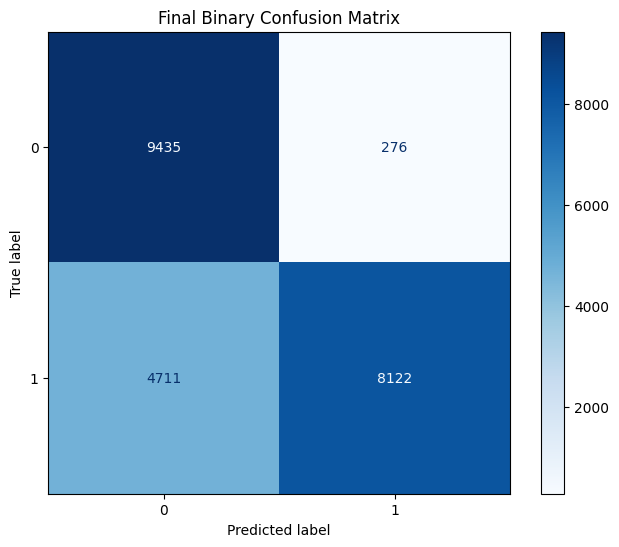

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(yb_test_full, y_pred_custom)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Final Binary Confusion Matrix")
plt.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report
import numpy as np

# =========================
# 1. Base Random Forest classifier (binary)
# =========================
rf_base_bin = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# =========================
# 2. Pipeline: preprocessing + Random Forest
# =========================
pipeline_rf_bin = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_base_bin)
])

# =========================
# 3. Hyperparameter search space
# =========================
search_space_rf_bin = {
    'classifier__n_estimators': [300, 500, 800],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

# =========================
# 4. Stratified CV
# =========================
strat_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 5. RandomizedSearchCV
# =========================
random_search_rf_bin = RandomizedSearchCV(
    estimator=pipeline_rf_bin,
    param_distributions=search_space_rf_bin,
    n_iter=25,
    scoring='f1_macro',
    cv=strat_cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# =========================
# 6. Train
# =========================
print("Starting Random Search (Macro-F1) for Random Forest (Binary)...")
random_search_rf_bin.fit(X_train_full, yb_train_full)

# =========================
# 7. Best model
# =========================
best_rf_model_bin = random_search_rf_bin.best_estimator_

print("Best CV Macro F1 Score:", random_search_rf_bin.best_score_)
print("Best Hyperparameters:", random_search_rf_bin.best_params_)

# =========================
# 8. Evaluation
# =========================
y_test_pred = best_rf_model_bin.predict(X_test_full)

print("\n--- Final Random Forest Binary Classification Report ---")
print(classification_report(yb_test_full, y_test_pred))

# =========================
# 9. Threshold adjustment
# =========================
y_probs = best_rf_model_bin.predict_proba(X_test_full)[:, 1]
custom_threshold = 0.5
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"\n--- Random Forest Binary Report (Threshold {custom_threshold}) ---")
print(classification_report(yb_test_full, y_pred_custom))


Starting Random Search (Macro-F1) for Random Forest (Binary)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Macro F1 Score: 0.9989390561121507
Best Hyperparameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20}

--- Final Random Forest Binary Classification Report ---
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.64      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544


--- Random Forest Binary Report (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.64      0.77     12833

    accuracy                         

In [42]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report
import numpy as np

# =========================
# 1. Base XGBoost classifier (binary)
# =========================
xgb_base_bin = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# =========================
# 2. Pipeline: preprocessing + XGBoost
# =========================
pipeline_xgb_bin = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_base_bin)
])

# =========================
# 3. Hyperparameter search space
# =========================
search_space_xgb_bin = {
    'classifier__n_estimators': [300, 500, 800, 1000],
    'classifier__learning_rate': [0.01, 0.03, 0.05],
    'classifier__max_depth': [3, 6, 10],
    'classifier__subsample': [0.7, 0.85, 1.0],
    'classifier__colsample_bytree': [0.7, 0.85, 1.0],
    'classifier__min_child_weight': [1, 5, 10],
    'classifier__reg_alpha': [0.0, 0.5, 1.0],
    'classifier__reg_lambda': [1.0, 2.0, 5.0]
}

# =========================
# 4. Stratified CV
# =========================
strat_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 5. RandomizedSearchCV
# =========================
random_search_xgb_bin = RandomizedSearchCV(
    estimator=pipeline_xgb_bin,
    param_distributions=search_space_xgb_bin,
    n_iter=25,
    scoring='f1_macro',
    cv=strat_cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# =========================
# 6. Train
# =========================
print("Starting Random Search (Macro-F1) for XGBoost (Binary)...")
random_search_xgb_bin.fit(X_train_full, yb_train_full)

# =========================
# 7. Best model
# =========================
best_xgb_model_bin = random_search_xgb_bin.best_estimator_

print("Best CV Macro F1 Score:", random_search_xgb_bin.best_score_)
print("Best Hyperparameters:", random_search_xgb_bin.best_params_)

# =========================
# 8. Evaluation
# =========================
y_test_pred = best_xgb_model_bin.predict(X_test_full)

print("\n--- Final XGBoost Binary Classification Report ---")
print(classification_report(yb_test_full, y_test_pred))

# =========================
# 9. Threshold adjustment
# =========================
y_probs = best_xgb_model_bin.predict_proba(X_test_full)[:, 1]
custom_threshold = 0.5
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f"\n--- XGBoost Binary Report (Threshold {custom_threshold}) ---")
print(classification_report(yb_test_full, y_pred_custom))


Starting Random Search (Macro-F1) for XGBoost (Binary)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Macro F1 Score: 0.999122556969614
Best Hyperparameters: {'classifier__subsample': 1.0, 'classifier__reg_lambda': 1.0, 'classifier__reg_alpha': 0.5, 'classifier__n_estimators': 800, 'classifier__min_child_weight': 1, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.7}

--- Final XGBoost Binary Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544


--- XGBoost Binary Report (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0

In [43]:
from sklearn.metrics import f1_score
import numpy as np

def tune_threshold(model, X, y, thresholds=np.arange(0.1, 0.9, 0.05)):
    probs = model.predict_proba(X)[:, 1]
    scores = []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        scores.append(f1_score(y, preds, average='macro'))

    best_t = thresholds[np.argmax(scores)]
    return best_t, max(scores)

best_threshold, best_cv_f1 = tune_threshold(
    best_lgbm_model_bin,
    X_train_full,
    yb_train_full
)

print(f"Best threshold (CV-based): {best_threshold}")
print(f"Best CV Macro F1: {best_cv_f1:.4f}")

Best threshold (CV-based): 0.20000000000000004
Best CV Macro F1: 0.9999



🔁 Generating out-of-fold probabilities...

🎯 Best Threshold (CV-based): 0.41
🎯 Best CV Macro F1: 0.9992

📊 FINAL XGBOOST BINARY CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.80     22544
weighted avg       0.85      0.81      0.80     22544



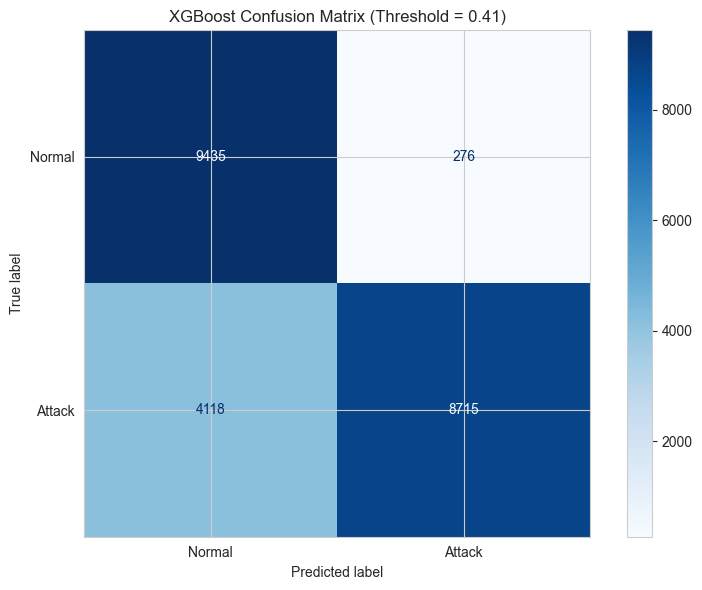

In [46]:
# =========================================================
# 5. OOF PROBABILITIES (NO LEAKAGE)
# =========================================================
from sklearn.model_selection import cross_val_predict

print("\n🔁 Generating out-of-fold probabilities...")

oof_probs = cross_val_predict(
    best_xgb_model_bin,
    X_train_full,
    yb_train_full,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# =========================================================
# 6. THRESHOLD TUNING FUNCTION (PROB-BASED)
# =========================================================
def tune_threshold_from_probs(probs, y_true, thresholds=np.arange(0.05, 0.95, 0.02)):
    scores = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        scores.append(f1_score(y_true, preds, average='macro'))

    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]

best_threshold, best_cv_f1 = tune_threshold_from_probs(
    oof_probs,
    yb_train_full
)

print(f"\n🎯 Best Threshold (CV-based): {best_threshold:.2f}")
print(f"🎯 Best CV Macro F1: {best_cv_f1:.4f}")

# =========================================================
# 7. APPLY THRESHOLD ON TEST SET (FINAL)
# =========================================================
y_test_probs = best_xgb_model_bin.predict_proba(X_test_full)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

# =========================================================
# 8. FINAL CLASSIFICATION REPORT
# =========================================================
print("\n📊 FINAL XGBOOST BINARY CLASSIFICATION REPORT")
print(classification_report(yb_test_full, y_test_pred))

# =========================================================
# 9. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(yb_test_full, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Attack']
)

disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"XGBoost Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.tight_layout()
plt.show()

In [47]:
from sklearn.metrics import average_precision_score
ap = average_precision_score(yb_test_full, y_probs_test)
print("PR-AUC:", ap)


PR-AUC: 0.9710030779561986


In [48]:
from sklearn.ensemble import (
    StackingClassifier, 
    VotingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score
import numpy as np
import pandas as pd
import warnings

### Bagging model

In [49]:
# -----------------------------
# Bagging: Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

### Boosting model

In [50]:
# -----------------------------
# Boosting: XGBoost
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# -----------------------------
# Boosting: LightGBM
# -----------------------------
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgbm_model)
])

# -----------------------------
# Boosting: Gradient Boosting
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    n_jobs=-1
)

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', knn_model)
])

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gb_model)
])

### Stacking model

In [52]:
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('knn', knn_model),
        ('rf', rf_model)
    ],
    final_estimator=LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    cv=5,
    n_jobs=-1
)

stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stacking_model)
])

### Voting model

In [55]:
voting_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('knn', knn_model),
        ('rf', rf_model),
    ],
    voting='soft',
    weights=[3, 2, 2, 1],
    n_jobs=-1
)

voting_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', voting_model)
])

### Evaluation function

In [56]:
# Prepare data
X_train = X_train_full
X_test = X_test_full
y_train = yb_train_full
y_test = yb_test_full

# Ensemble models only
ensemble_models = [
    (rf_pipeline, 'Bagging (Random Forest)'),
    (xgb_pipeline, 'Boosting (XGBoost)'),
    (lgbm_pipeline, 'Boosting (LightGBM)'),
    (gb_pipeline, 'Boosting (Gradient Boosting)'),
    (stacking_pipeline, 'Stacking Classifier'),
    (voting_pipeline, 'Voting Classifier')
]

# Store results
results = []

# Evaluate ensemble models
for model, name in ensemble_models:
    print(f"Evaluating {name}...")
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    recall_macro = recall_score(y_test, y_pred, average='macro')
    
    # Cross-validation F1-macro
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    # Append results
    results.append({
        'model': name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'recall_macro': recall_macro,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std()
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)

# Display
print("\nENSEMBLE MODEL PERFORMANCE COMPARISON")
print(results_df.to_string(index=False))

Evaluating Bagging (Random Forest)...
Evaluating Boosting (XGBoost)...
Evaluating Boosting (LightGBM)...
Evaluating Boosting (Gradient Boosting)...
Evaluating Stacking Classifier...
Evaluating Voting Classifier...

ENSEMBLE MODEL PERFORMANCE COMPARISON
                       model  accuracy  f1_macro  f1_weighted  recall_macro  cv_f1_mean  cv_f1_std
Boosting (Gradient Boosting)  0.811746  0.811621     0.810950      0.831251    0.998612   0.000312
          Boosting (XGBoost)  0.795733  0.795384     0.794214      0.817123    0.999098   0.000182
         Stacking Classifier  0.792007  0.791584     0.790285      0.813850    0.999035   0.000185
           Voting Classifier  0.789478  0.789001     0.787612      0.811629    0.999027   0.000180
         Boosting (LightGBM)  0.787127  0.786590     0.785108      0.809602    0.998508   0.000312
     Bagging (Random Forest)  0.768364  0.767212     0.764944      0.793321    0.998763   0.000318



CLASSIFICATION REPORT – Boosting (Gradient Boosting)

              precision    recall  f1-score   support

           0       0.70      0.97      0.82      9711
           1       0.97      0.69      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.86      0.81      0.81     22544



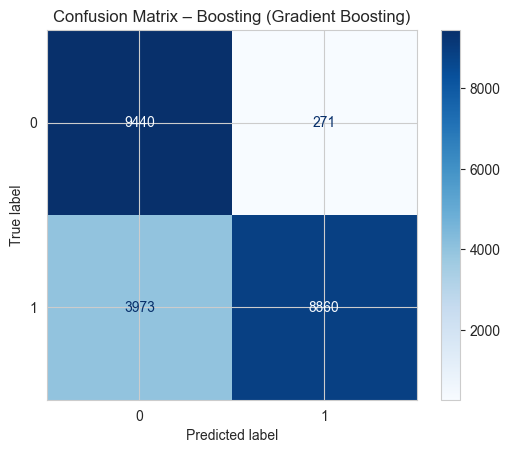

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gradient Boosting pipeline is ALREADY trained
y_pred_gb = gb_pipeline.predict(X_test)

# Classification Report
print("\nCLASSIFICATION REPORT  Boosting (Gradient Boosting)\n")
print(classification_report(y_test, y_pred_gb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix  Boosting (Gradient Boosting)")
plt.show()

In [ ]:
# -------------------- Save final pipeline --------------------
with open('../models/final_pipeline.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# -------------------- Load pipeline example --------------------
with open('../models/final_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Example: adjust these to your dataset
num_cols = X_train_full.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train_full.select_dtypes(include=['object', 'category']).columns

# 🔹 Preprocessor for TREE models
tree_preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 🔹 Preprocessor for DISTANCE models (KNN)
knn_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [60]:
# ✅ 2. MODELS (CLEAN & CORRECT)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 🔹 Random Forest (Bagging)
rf_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

# 🔹 Gradient Boosting (CLASSICAL – your best)
gb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

# 🔹 XGBoost (REGULARIZED)
xgb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=1,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# 🔹 LightGBM (REGULARIZED)
lgbm_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=200,
        max_depth=4,
        num_leaves=15,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# 🔹 KNN (FIXED)
knn_pipeline = Pipeline([
    ('preprocessor', knn_preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        n_jobs=-1
    ))
])


Training Random Forest...

Training Gradient Boosting...

Training XGBoost...

Training LightGBM...

Training KNN...


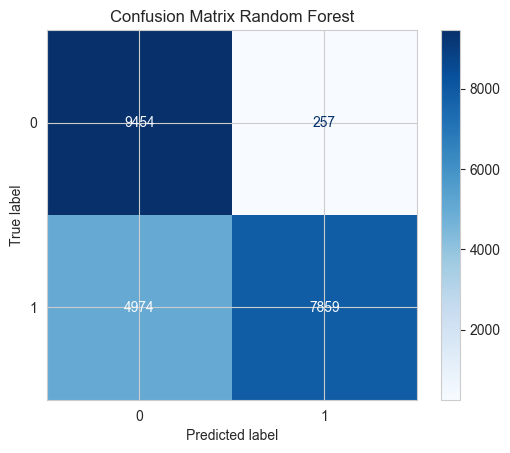

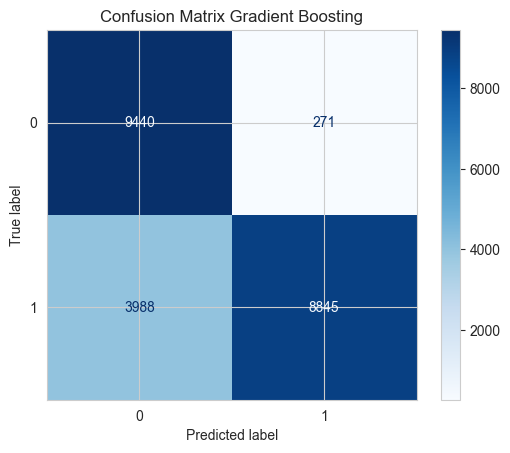

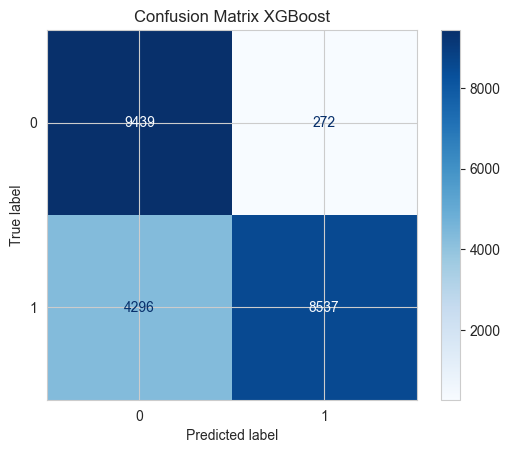

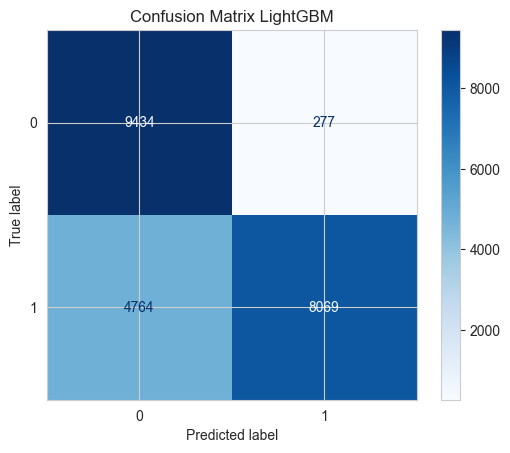

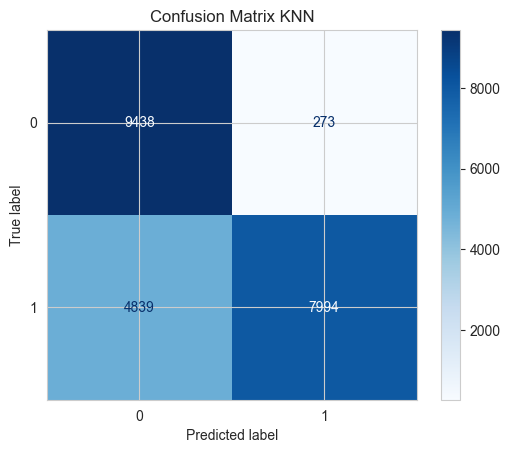


CLASSIFICATION REPORT Random Forest
              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544


CLASSIFICATION REPORT Gradient Boosting
              precision    recall  f1-score   support

           0       0.70      0.97      0.82      9711
           1       0.97      0.69      0.81     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.86      0.81      0.81     22544


CLASSIFICATION REPORT XGBoost
              precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       

In [62]:
# ✅ 3. TRAIN + EVALUATION (ONE LOOP)
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    (rf_pipeline, 'Random Forest'),
    (gb_pipeline, 'Gradient Boosting'),
    (xgb_pipeline, 'XGBoost'),
    (lgbm_pipeline, 'LightGBM'),
    (knn_pipeline, 'KNN')
]

results = {}

for model, name in models:
    print(f"\nTraining {name}...")
    
    model.fit(X_train_full, yb_train_full)
    y_pred = model.predict(X_test_full)
    
    results[name] = {
        'accuracy': accuracy_score(yb_test_full, y_pred),
        'f1_macro': f1_score(yb_test_full, y_pred, average='macro'),
        'f1_weighted': f1_score(yb_test_full, y_pred, average='weighted'),
        'recall_macro': recall_score(yb_test_full, y_pred, average='macro'),
        'confusion_matrix': confusion_matrix(yb_test_full, y_pred),
        'classification_report': classification_report(yb_test_full, y_pred)
    }

# ✅ 4. COMPARISON DATAFRAME
comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': v['accuracy'],
        'F1 Macro': v['f1_macro'],
        'F1 Weighted': v['f1_weighted'],
        'Recall Macro': v['recall_macro']
    }
    for name, v in results.items()
]).sort_values('F1 Macro', ascending=False)

comparison_df



# ✅ 5. CONFUSION MATRICES (ALL MODELS)
for name, v in results.items():
    disp = ConfusionMatrixDisplay(v['confusion_matrix'])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix {name}")
    plt.show()

# ✅ 6. CLASSIFICATION REPORTS (ALL MODELS)
for name, v in results.items():
    print("\n" + "="*80)
    print(f"CLASSIFICATION REPORT {name}")
    print("="*80)
    print(v['classification_report'])


In [68]:
pip install --upgrade xgboost imbalanced-learn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Asus\\network_intrution_detection\\venv\\Lib\\site-packages\\~gboost\\lib\\xgboost.dll'
Check the permissions.


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
# === Imports ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings("ignore")

# === 1) Prepare train/test data ===
X_train_full = train_df.drop(columns=target_cols)
X_test_full = test_df.drop(columns=target_cols)

yb_train_full = train_df['is_attack_binary']
yb_test_full = test_df['is_attack_binary']

# === 2) Identify numeric & categorical columns ===
num_cols = X_train_full.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object","category"]).columns.tolist()
print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

# === 3) Build preprocessing pipeline ===
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder="drop"
)

# === 4) Feature selection param ===
K = 40  # number of features to keep after SelectKBest

# === 5) Create validation set from training set (leave test untouched) ===
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)

# === 6) Fit preprocessor and transform datasets ===
X_tr_enc = preprocessor.fit_transform(X_tr)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)

# === 7) Feature selection using mutual information ===
selector = SelectKBest(score_func=mutual_info_classif, k=min(K, X_tr_enc.shape[1]))
selector.fit(X_tr_enc, y_tr)

X_tr_sel = selector.transform(X_tr_enc)
X_val_sel = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Original encoded dims:", X_tr_enc.shape)
print("Selected features dims:", X_tr_sel.shape)

# === 8) Apply SMOTE on training data only ===
sm = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sel, y_tr)
print("After SMOTE, class counts:", np.bincount(y_tr_bal))

# === 9) Train XGBoost using DMatrix (works for all versions) ===
dtrain = xgb.DMatrix(X_tr_bal, label=y_tr_bal)
dval = xgb.DMatrix(X_val_sel, label=y_val)
dtest = xgb.DMatrix(X_test_sel)

params = {
    "objective": "binary:logistic",
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "alpha": 0.5,
    "lambda": 1.0,
    "eval_metric": "logloss",
    "seed": 42
}

evals = [(dtrain, "train"), (dval, "validation")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50
)

# === 10) Save preprocessor, selector, and model for reuse ===
joblib.dump(preprocessor, "preprocessor.joblib")
joblib.dump(selector, "selector.joblib")
bst.save_model("xgb_model.json")  # save xgb.train model

# === 11) Threshold tuning on validation set ===
probs_val = bst.predict(dval)
thresholds = np.linspace(0.01, 0.99, 99)
f1s = np.array([f1_score(y_val, probs_val > t) for t in thresholds])
best_t = thresholds[np.argmax(f1s)]
print("Best threshold on validation:", best_t, "F1:", f1s.max())

# === 12) Final evaluation on test set ===
probs_test = bst.predict(dtest)
y_test_pred = (probs_test > best_t).astype(int)

print(f"=== Classification report (Test) at threshold {best_t:.2f} ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(yb_test_full, y_test_pred, average='binary')
acc = (y_test_pred == yb_test_full).mean()
print(f"Test Accuracy: {acc:.4f}   Precision: {precision:.4f}   Recall: {recall:.4f}   F1: {f1:.4f}")


Numeric features: 32
Categorical features: 3
Original encoded dims: (107077, 115)
Selected features dims: (107077, 40)
After SMOTE, class counts: [57242 57242]
[0]	train-logloss:0.64825	validation-logloss:0.64841
[50]	train-logloss:0.08427	validation-logloss:0.08368
[100]	train-logloss:0.03483	validation-logloss:0.03361
[150]	train-logloss:0.02312	validation-logloss:0.02178
[200]	train-logloss:0.01680	validation-logloss:0.01555
[250]	train-logloss:0.01299	validation-logloss:0.01212
[300]	train-logloss:0.01027	validation-logloss:0.00983
[350]	train-logloss:0.00861	validation-logloss:0.00841
[400]	train-logloss:0.00740	validation-logloss:0.00738
[450]	train-logloss:0.00644	validation-logloss:0.00660
[500]	train-logloss:0.00571	validation-logloss:0.00597
[550]	train-logloss:0.00501	validation-logloss:0.00543
[600]	train-logloss:0.00445	validation-logloss:0.00505
[650]	train-logloss:0.00399	validation-logloss:0.00471
[700]	train-logloss:0.00361	validation-logloss:0.00444
[750]	train-loglos

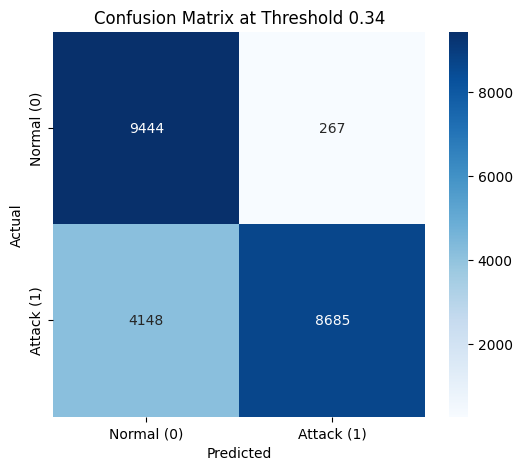

In [33]:
# === 13) Confusion Matrix ===
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(yb_test_full, y_test_pred)
cm_labels = ["Normal (0)", "Attack (1)"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix at Threshold {best_t:.2f}")
plt.show()


In [36]:
# === Imports ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support
from sklearn.ensemble import AdaBoostClassifier
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings("ignore")

# === 1) Prepare train/test data ===
X_train_full = train_df.drop(columns=target_cols)
X_test_full = test_df.drop(columns=target_cols)

yb_train_full = train_df['is_attack_binary']
yb_test_full = test_df['is_attack_binary']

# === 2) Identify numeric & categorical columns ===
num_cols = X_train_full.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object","category"]).columns.tolist()

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

# === 3) Build preprocessing pipeline ===
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder="drop"
)

# === 4) Feature selection param ===
K = 40

# === 5) Create validation set ===
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)

# === 6) Encode data ===
X_tr_enc = preprocessor.fit_transform(X_tr)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)

# === 7) Feature selection ===
selector = SelectKBest(score_func=mutual_info_classif, k=min(K, X_tr_enc.shape[1]))
selector.fit(X_tr_enc, y_tr)

X_tr_sel = selector.transform(X_tr_enc)
X_val_sel = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Encoded dims:", X_tr_enc.shape)
print("Selected dims:", X_tr_sel.shape)

# === 8) Apply SMOTE ===
sm = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sel, y_tr)

print("After SMOTE:", np.bincount(y_tr_bal))

# === 9) Train AdaBoost ===
ada = AdaBoostClassifier(
    n_estimators=400,
    learning_rate=0.05,
    algorithm="SAMME",
    random_state=42
)

ada.fit(X_tr_bal, y_tr_bal)

# === 10) Save artifacts ===
joblib.dump(preprocessor, "preprocessor.joblib")
joblib.dump(selector, "selector.joblib")
joblib.dump(ada, "adaboost_model.joblib")

# === 11) Threshold tuning (Validation set) ===
probs_val = ada.predict_proba(X_val_sel)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
f1s = np.array([f1_score(y_val, probs_val > t) for t in thresholds])

best_t = thresholds[np.argmax(f1s)]
print("Best threshold:", best_t, "Best F1:", f1s.max())

# === 12) Final evaluation (Test set) ===
probs_test = ada.predict_proba(X_test_sel)[:, 1]
y_test_pred = (probs_test > best_t).astype(int)

print(f"\n=== Classification Report (AdaBoost | threshold={best_t:.2f}) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(
    yb_test_full, y_test_pred, average='binary'
)
acc = (y_test_pred == yb_test_full).mean()

print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

Numeric features: 32
Categorical features: 3
Encoded dims: (107077, 115)
Selected dims: (107077, 40)
After SMOTE: [57242 57242]
Best threshold: 0.54 Best F1: 0.9613738936756345

=== Classification Report (AdaBoost | threshold=0.54) ===
              precision    recall  f1-score   support

           0     0.6240    0.9767    0.7615      9711
           1     0.9692    0.5546    0.7055     12833

    accuracy                         0.7364     22544
   macro avg     0.7966    0.7657    0.7335     22544
weighted avg     0.8205    0.7364    0.7296     22544

Accuracy: 0.7364 | Precision: 0.9692 | Recall: 0.5546 | F1: 0.7055


In [25]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


# =========================
# 1) Prepare data
# =========================
X_train_full = train_df.drop(columns=target_cols)
X_test_full  = test_df.drop(columns=target_cols)

yb_train_full = train_df["is_attack_binary"]
yb_test_full  = test_df["is_attack_binary"]


# =========================
# 2) Identify column types
# =========================
num_cols = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))


# =========================
# 3) Preprocessing pipeline
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)


# =========================
# 4) Feature selection
# =========================
K = 70  # tuned for NSL-KDD


# =========================
# 5) Train / Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)


# =========================
# 6) Encode data
# =========================
X_tr_enc   = preprocessor.fit_transform(X_tr)
X_val_enc  = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)


# =========================
# 7) Feature selection
# =========================
selector = SelectKBest(
    mutual_info_classif,
    k=min(K, X_tr_enc.shape[1])
)

X_tr_sel   = selector.fit_transform(X_tr_enc, y_tr)
X_val_sel  = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Encoded shape:", X_tr_enc.shape)
print("Selected shape:", X_tr_sel.shape)


# =========================
# 8) SMOTE (attack-aware)
# =========================
sm = SMOTE(
    sampling_strategy=0.9,   # not fully 50-50 (reduces noise)
    random_state=42,
    k_neighbors=5
)

X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sel, y_tr)
print("After SMOTE:", np.bincount(y_tr_bal))


# =========================
# 9) XGBoost IDS model
# =========================
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,

    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=1.0,

    scale_pos_weight=1.2,   # attack bias
    tree_method="hist",     # FAST

    random_state=42,
    n_jobs=-1
)

xgb.fit(X_tr_bal, y_tr_bal)





# =========================
# 11) Threshold tuning (F1)
# =========================
probs_val = xgb.predict_proba(X_val_sel)[:, 1]

thresholds = np.linspace(0.15, 0.6, 60)
f1s = [f1_score(y_val, probs_val >= t) for t in thresholds]

best_t = thresholds[np.argmax(f1s)]
print(f"Best threshold: {best_t:.2f} | Best F1: {max(f1s):.4f}")


# =========================
# 12) Final test evaluation
# =========================
probs_test = xgb.predict_proba(X_test_sel)[:, 1]
y_test_pred = (probs_test >= best_t).astype(int)

print("\n=== FINAL CLASSIFICATION REPORT (XGBOOST IDS) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(
    yb_test_full,
    y_test_pred,
    average="binary"
)

acc = (y_test_pred == yb_test_full).mean()

print(
    f"Accuracy: {acc:.4f} | "
    f"Precision: {precision:.4f} | "
    f"Recall: {recall:.4f} | "
    f"F1: {f1:.4f}"
)


Numeric features: 32
Categorical features: 3
Encoded shape: (107077, 115)
Selected shape: (107077, 70)
After SMOTE: [57242 51517]
Best threshold: 0.24 | Best F1: 0.9991

=== FINAL CLASSIFICATION REPORT (XGBOOST IDS) ===
              precision    recall  f1-score   support

           0     0.7130    0.9689    0.8215      9711
           1     0.9677    0.7048    0.8156     12833

    accuracy                         0.8186     22544
   macro avg     0.8403    0.8369    0.8185     22544
weighted avg     0.8580    0.8186    0.8181     22544

Accuracy: 0.8186 | Precision: 0.9677 | Recall: 0.7048 | F1: 0.8156


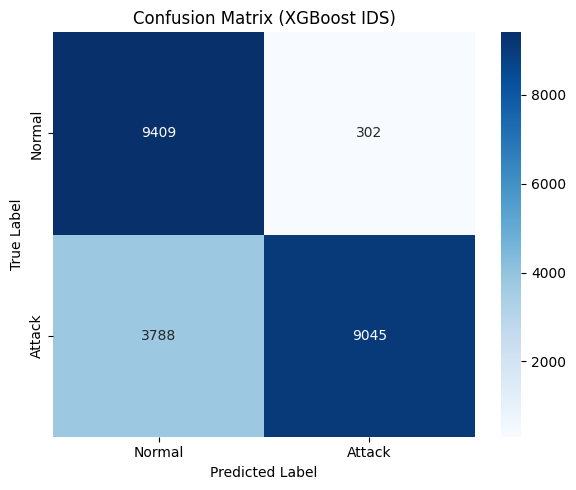

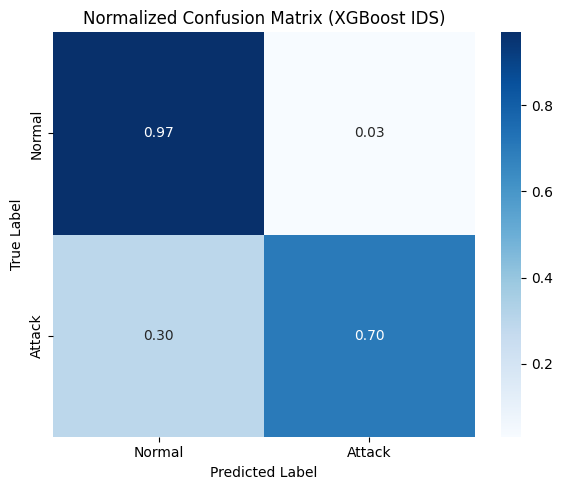

In [26]:
# =========================
# 13) Confusion Matrix
# =========================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(yb_test_full, y_test_pred)

# Labels
labels = ["Normal", "Attack"]

# ---- Raw confusion matrix ----
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (XGBoost IDS)")
plt.tight_layout()
plt.show()

# ---- Normalized confusion matrix ----
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (XGBoost IDS)")
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support
)

from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier


# =========================
# 1) Prepare data
# =========================
X_train_full = train_df.drop(columns=target_cols)
X_test_full  = test_df.drop(columns=target_cols)

yb_train_full = train_df["is_attack_binary"]
yb_test_full  = test_df["is_attack_binary"]


# =========================
# 2) Identify column types
# =========================
num_cols = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))


# =========================
# 3) Preprocessing pipeline
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)


# =========================
# 4) Feature selection
# =========================
K = 70   # Optimal for NSL-KDD


# =========================
# 5) Train / Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)


# =========================
# 6) Encode data
# =========================
X_tr_enc   = preprocessor.fit_transform(X_tr)
X_val_enc  = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)


# =========================
# 7) Feature selection
# =========================
selector = SelectKBest(
    mutual_info_classif,
    k=min(K, X_tr_enc.shape[1])
)

X_tr_sel   = selector.fit_transform(X_tr_enc, y_tr)
X_val_sel  = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Encoded shape:", X_tr_enc.shape)
print("Selected shape:", X_tr_sel.shape)


# =========================
# 8) BorderlineSMOTE (BEST for IDS)
# =========================
sm = BorderlineSMOTE(
    sampling_strategy="auto",   # avoids unrealistic balance
    k_neighbors=5,
    random_state=42
)

X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sel, y_tr)
print("After BorderlineSMOTE:", np.bincount(y_tr_bal))


# =========================
# 9) XGBoost IDS model
# =========================
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",

    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,

    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=1.0,

    scale_pos_weight=1.0,    # IMPORTANT: neutral (SMOTE already handled imbalance)
    tree_method="hist",      # FAST & memory efficient

    random_state=42,
    n_jobs=-1
)

xgb.fit(X_tr_bal, y_tr_bal)


# =========================
# 10) Threshold tuning (F1 – IDS metric)
# =========================
probs_val = xgb.predict_proba(X_val_sel)[:, 1]

thresholds = np.linspace(0.15, 0.6, 60)
f1s = [f1_score(y_val, probs_val >= t) for t in thresholds]

best_t = thresholds[np.argmax(f1s)]
print(f"Best threshold: {best_t:.2f} | Best F1: {max(f1s):.4f}")


# =========================
# 11) Final test evaluation
# =========================
probs_test = xgb.predict_proba(X_test_sel)[:, 1]
y_test_pred = (probs_test >= best_t).astype(int)

print("\n=== FINAL CLASSIFICATION REPORT (XGBOOST IDS) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(
    yb_test_full,
    y_test_pred,
    average="binary"
)

acc = (y_test_pred == yb_test_full).mean()

print(
    f"Accuracy: {acc:.4f} | "
    f"Precision: {precision:.4f} | "
    f"Recall: {recall:.4f} | "
    f"F1: {f1:.4f}"
)

Numeric features: 32
Categorical features: 3
Encoded shape: (107077, 115)
Selected shape: (107077, 70)
After BorderlineSMOTE: [57242 57242]
Best threshold: 0.49 | Best F1: 0.9990

=== FINAL CLASSIFICATION REPORT (XGBOOST IDS) ===
              precision    recall  f1-score   support

           0     0.7236    0.9686    0.8284      9711
           1     0.9680    0.7200    0.8258     12833

    accuracy                         0.8271     22544
   macro avg     0.8458    0.8443    0.8271     22544
weighted avg     0.8627    0.8271    0.8269     22544

Accuracy: 0.8271 | Precision: 0.9680 | Recall: 0.7200 | F1: 0.8258


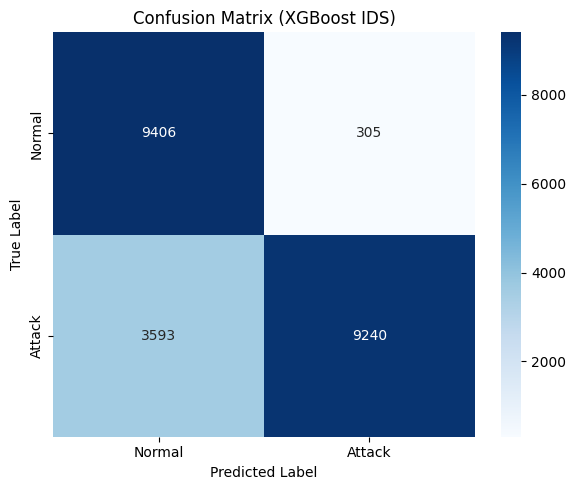

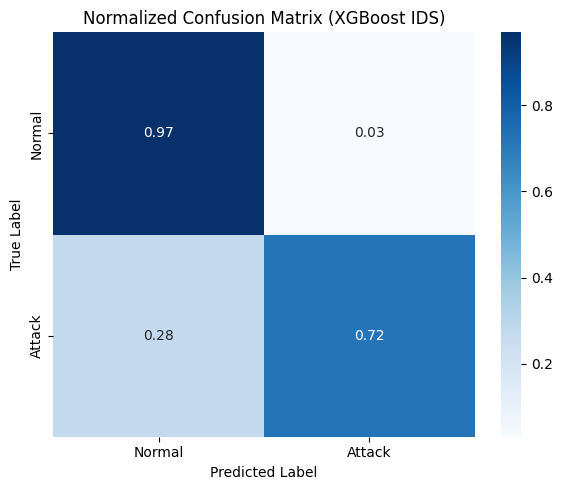

In [30]:
# =========================
# 13) Confusion Matrix
# =========================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(yb_test_full, y_test_pred)

# Labels
labels = ["Normal", "Attack"]

# ---- Raw confusion matrix ----
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (XGBoost IDS)")
plt.tight_layout()
plt.show()

# ---- Normalized confusion matrix ----
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (XGBoost IDS)")
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, make_scorer

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import time

# =========================
# 1) Prepare data
# =========================
X_train_full = train_df.drop(columns=target_cols)
X_test_full  = test_df.drop(columns=target_cols)

yb_train_full = train_df["is_attack_binary"]
yb_test_full  = test_df["is_attack_binary"]

# =========================
# 2) Identify column types
# =========================
num_cols = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

# =========================
# 3) Preprocessing pipeline
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

# =========================
# 4) Feature selection
# =========================
K = 70   # Optimal for NSL-KDD

# =========================
# 5) Train / Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)

# =========================
# 6) Encode data
# =========================
X_tr_enc   = preprocessor.fit_transform(X_tr)
X_val_enc  = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)

# =========================
# 7) Feature selection
# =========================
selector = SelectKBest(mutual_info_classif, k=min(K, X_tr_enc.shape[1]))

X_tr_sel   = selector.fit_transform(X_tr_enc, y_tr)
X_val_sel  = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Encoded shape:", X_tr_enc.shape)
print("Selected shape:", X_tr_sel.shape)

# =========================
# 8) HYPERPARAMETER TUNING (RandomizedSearchCV) + SMOTE pipeline
# =========================
f1_attack = make_scorer(f1_score, pos_label=1)

pipe = ImbPipeline([
    ("smote", BorderlineSMOTE(sampling_strategy="auto", k_neighbors=5, random_state=42)),
    ("clf", XGBClassifier(objective="binary:logistic", tree_method="hist", use_label_encoder=False,
                          eval_metric="logloss", n_jobs=-1, random_state=42))
])

param_dist = {
    "clf__n_estimators": randint(200, 1200),
    "clf__max_depth": randint(3, 12),
    "clf__learning_rate": uniform(0.01, 0.3),
    "clf__min_child_weight": randint(1, 20),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__gamma": uniform(0.0, 0.5),
    "clf__reg_alpha": uniform(0.0, 1.0),
    "clf__reg_lambda": uniform(0.5, 2.0),
    "clf__scale_pos_weight": [1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=f1_attack,
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV...")
t0 = time.time()
rs.fit(X_tr_sel, y_tr)
t1 = time.time()
print(f"RandomizedSearchCV done in {(t1-t0)/60:.2f} minutes")

print("Best CV score (F1 attack):", rs.best_score_)
best_params = rs.best_params_
for k, v in best_params.items():
    print(f"{k}: {v}")

# =========================
# 9) Refit final model using xgb.train (compatible with older xgboost)
# =========================
# Extract best clf params
clf_best_params = {k.replace("clf__", ""): v for k, v in best_params.items() if k.startswith("clf__")}

# Re-sample training set with BorderlineSMOTE
sm_final = BorderlineSMOTE(sampling_strategy="auto", k_neighbors=5, random_state=42)
X_tr_bal, y_tr_bal = sm_final.fit_resample(X_tr_sel, y_tr)
print("Resampled train class counts:", np.bincount(y_tr_bal))

# Prepare DMatrix
dtrain = xgb.DMatrix(X_tr_bal, label=y_tr_bal)
dval = xgb.DMatrix(X_val_sel, label=y_val)

params = {
    "objective": "binary:logistic",
    "tree_method": "hist",
    "learning_rate": clf_best_params["learning_rate"],
    "max_depth": int(clf_best_params["max_depth"]),
    "min_child_weight": clf_best_params["min_child_weight"],
    "subsample": clf_best_params["subsample"],
    "colsample_bytree": clf_best_params["colsample_bytree"],
    "gamma": clf_best_params["gamma"],
    "reg_alpha": clf_best_params["reg_alpha"],
    "reg_lambda": clf_best_params["reg_lambda"],
    "scale_pos_weight": 1.0,
    "eval_metric": "logloss",
    "seed": 42
}

evals = [(dtrain, "train"), (dval, "val")]

num_boost_round = int(clf_best_params["n_estimators"])

print("\nTraining final XGBoost with early stopping using xgb.train...")
final_xgb = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=25
)

# =========================
# 10) Threshold tuning
# =========================
probs_val = final_xgb.predict(dval)
thresholds = np.linspace(0.10, 0.6, 100)
f1s = [f1_score(y_val, probs_val >= t) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
print(f"\nChosen threshold (validation F1): {best_t:.3f} | Best val F1: {max(f1s):.4f}")

# =========================
# 11) Evaluate on test set
# =========================
dtest = xgb.DMatrix(X_test_sel)
probs_test = final_xgb.predict(dtest)
y_test_pred = (probs_test >= best_t).astype(int)

print("\n=== FINAL EVAL (Hyper-tuned XGBoost) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(yb_test_full, y_test_pred, average="binary")
acc = (y_test_pred == yb_test_full).mean()
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


Numeric features: 32
Categorical features: 3
Encoded shape: (107077, 115)
Selected shape: (107077, 70)
Starting RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
RandomizedSearchCV done in 20.23 minutes
Best CV score (F1 attack): 0.998775907841205
clf__colsample_bytree: 0.821105986734196
clf__gamma: 0.28614623458541916
clf__learning_rate: 0.3040994751148137
clf__max_depth: 6
clf__min_child_weight: 1
clf__n_estimators: 455
clf__reg_alpha: 0.4852798742763157
clf__reg_lambda: 1.2453737341880986
clf__scale_pos_weight: 1.0
clf__subsample: 0.7578765867237889
Resampled train class counts: [57242 57242]

Training final XGBoost with early stopping using xgb.train...
[0]	train-logloss:0.44915	val-logloss:0.44445
[25]	train-logloss:0.00762	val-logloss:0.00702
[50]	train-logloss:0.00223	val-logloss:0.00401
[75]	train-logloss:0.00124	val-logloss:0.00347
[100]	train-logloss:0.00102	val-logloss:0.00345
[125]	train-logloss:0.00095	val-logloss:0.00341
[150]	train-loglo


Confusion Matrix (Test Set):
[[9368  343]
 [3491 9342]]

TN: 9368, FP: 343, FN: 3491, TP: 9342


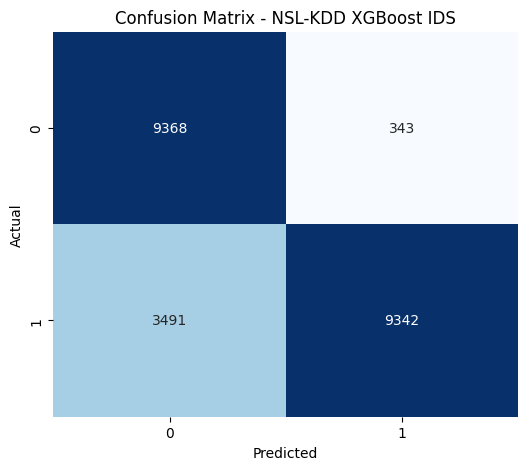

In [33]:
# =========================
# 12) Confusion Matrix
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(yb_test_full, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - NSL-KDD XGBoost IDS")
plt.show()


Numeric features    : 32
Categorical features: 3
Encoded shape : (100778, 115)
Selected shape: (100778, 70)
Resampled train class distribution: [53874 53874]

===== FINAL EVALUATION : RF–SMOTE =====
              precision    recall  f1-score   support

           0     0.6727    0.9721    0.7951      9711
           1     0.9682    0.6421    0.7721     12833

    accuracy                         0.7842     22544
   macro avg     0.8204    0.8071    0.7836     22544
weighted avg     0.8409    0.7842    0.7820     22544

Accuracy : 0.7842
Precision: 0.9682
Recall   : 0.6421
F1 Score : 0.7721

Confusion Matrix:
[[9440  271]
 [4593 8240]]
TN: 9440 | FP: 271 | FN: 4593 | TP: 8240


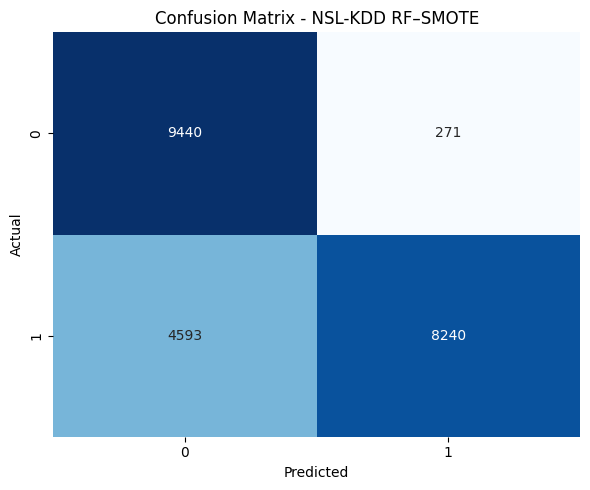

In [20]:
# =========================================================
# RF–SMOTE : Binary Intrusion Detection (NSL-KDD)
# Paper-aligned with Saputra et al., 2025
# =========================================================

# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# 1) Prepare data
# =========================
# Assumes:
# - train_df, test_df already loaded
# - target column: "is_attack_binary"
# - target_cols contains all target columns

X_train_full = train_df.drop(columns=target_cols)
X_test_full  = test_df.drop(columns=target_cols)

y_train_full = train_df["is_attack_binary"]
y_test_full  = test_df["is_attack_binary"]


# =========================
# 2) Identify column types
# =========================
num_cols = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric features    : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")


# =========================
# 3) Preprocessing
# (Paper uses Min–Max normalization)
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)


# =========================
# 4) Feature selection
# =========================
K = 70  # Reported as optimal for NSL-KDD


# =========================
# 5) Train / Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)


# =========================
# 6) Encode data
# =========================
X_tr_enc   = preprocessor.fit_transform(X_tr)
X_val_enc  = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)


# =========================
# 7) Feature selection (Mutual Information)
# =========================

X_tr_sel   = selector.fit_transform(X_tr_enc, y_tr)
X_val_sel  = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Encoded shape :", X_tr_enc.shape)
print("Selected shape:", X_tr_sel.shape)


# =========================
# 8) Apply SMOTE (TRAIN ONLY)
# =========================
smote = SMOTE(
    sampling_strategy="auto",
    k_neighbors=5,
    random_state=42
)

X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_sel, y_tr)

print("Resampled train class distribution:",
      np.bincount(y_tr_bal))


# =========================
# 9) Train Random Forest (Paper Parameters)
# =========================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_tr_bal, y_tr_bal)


# =========================
# 10) Evaluate on test set
# =========================
y_test_pred = rf.predict(X_test_sel)

print("\n===== FINAL EVALUATION : RF–SMOTE =====")
print(classification_report(y_test_full, y_test_pred, digits=4))

acc  = accuracy_score(y_test_full, y_test_pred)
prec = precision_score(y_test_full, y_test_pred)
rec  = recall_score(y_test_full, y_test_pred)
f1   = f1_score(y_test_full, y_test_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


# =========================
# 11) Confusion Matrix
# =========================
cm = confusion_matrix(y_test_full, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)
print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - NSL-KDD RF–SMOTE")
plt.tight_layout()
plt.show()


In [21]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, make_scorer

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import time

# =========================
# 1) Prepare data
# =========================
X_train_full = train_df.drop(columns=target_cols)
X_test_full  = test_df.drop(columns=target_cols)

yb_train_full = train_df["is_attack_binary"]
yb_test_full  = test_df["is_attack_binary"]

# =========================
# 2) Identify column types
# =========================
num_cols = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

# =========================
# 3) Preprocessing pipeline
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

# =========================
# 4) Feature selection
# =========================
K = 70   # Optimal for NSL-KDD

# =========================
# 5) Train / Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)

# =========================
# 6) Encode data
# =========================
X_tr_enc   = preprocessor.fit_transform(X_tr)
X_val_enc  = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)

# =========================
# 7) Feature selection
# =========================
selector = SelectKBest(mutual_info_classif, k=min(K, X_tr_enc.shape[1]))

X_tr_sel   = selector.fit_transform(X_tr_enc, y_tr)
X_val_sel  = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Encoded shape:", X_tr_enc.shape)
print("Selected shape:", X_tr_sel.shape)

# =========================
# 8) HYPERPARAMETER TUNING (RandomizedSearchCV) + SMOTE pipeline
# =========================
f1_attack = make_scorer(f1_score, pos_label=1)

pipe = ImbPipeline([
    ("smote", BorderlineSMOTE(sampling_strategy="auto", k_neighbors=5, random_state=42)),
    ("clf", XGBClassifier(objective="binary:logistic", tree_method="hist", use_label_encoder=False,
                          eval_metric="logloss", n_jobs=-1, random_state=42))
])

param_dist = {
    "clf__n_estimators": randint(200, 1200),
    "clf__max_depth": randint(3, 12),
    "clf__learning_rate": uniform(0.01, 0.3),
    "clf__min_child_weight": randint(1, 20),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__gamma": uniform(0.0, 0.5),
    "clf__reg_alpha": uniform(0.0, 1.0),
    "clf__reg_lambda": uniform(0.5, 2.0),
    "clf__scale_pos_weight": [1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=f1_attack,
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV...")
t0 = time.time()
rs.fit(X_tr_sel, y_tr)
t1 = time.time()
print(f"RandomizedSearchCV done in {(t1-t0)/60:.2f} minutes")

print("Best CV score (F1 attack):", rs.best_score_)
best_params = rs.best_params_
for k, v in best_params.items():
    print(f"{k}: {v}")

# =========================
# 9) Refit final model using xgb.train (compatible with older xgboost)
# =========================
# Extract best clf params
clf_best_params = {k.replace("clf__", ""): v for k, v in best_params.items() if k.startswith("clf__")}

# Re-sample training set with BorderlineSMOTE
sm_final = BorderlineSMOTE(sampling_strategy="auto", k_neighbors=5, random_state=42)
X_tr_bal, y_tr_bal = sm_final.fit_resample(X_tr_sel, y_tr)
print("Resampled train class counts:", np.bincount(y_tr_bal))

# Prepare DMatrix
dtrain = xgb.DMatrix(X_tr_bal, label=y_tr_bal)
dval = xgb.DMatrix(X_val_sel, label=y_val)

params = {
    "objective": "binary:logistic",
    "tree_method": "hist",
    "learning_rate": clf_best_params["learning_rate"],
    "max_depth": int(clf_best_params["max_depth"]),
    "min_child_weight": clf_best_params["min_child_weight"],
    "subsample": clf_best_params["subsample"],
    "colsample_bytree": clf_best_params["colsample_bytree"],
    "gamma": clf_best_params["gamma"],
    "reg_alpha": clf_best_params["reg_alpha"],
    "reg_lambda": clf_best_params["reg_lambda"],
    "scale_pos_weight": 1.0,
    "eval_metric": "logloss",
    "seed": 42
}

evals = [(dtrain, "train"), (dval, "val")]

num_boost_round = int(clf_best_params["n_estimators"])

print("\nTraining final XGBoost with early stopping using xgb.train...")
final_xgb = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=25
)

# =========================
# 10) Threshold tuning
# =========================
probs_val = final_xgb.predict(dval)
thresholds = np.linspace(0.10, 0.6, 100)
f1s = [f1_score(y_val, probs_val >= t) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
print(f"\nChosen threshold (validation F1): {best_t:.3f} | Best val F1: {max(f1s):.4f}")

# =========================
# 11) Evaluate on test set
# =========================
dtest = xgb.DMatrix(X_test_sel)
probs_test = final_xgb.predict(dtest)
y_test_pred = (probs_test >= best_t).astype(int)

print("\n=== FINAL EVAL (Hyper-tuned XGBoost) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(yb_test_full, y_test_pred, average="binary")
acc = (y_test_pred == yb_test_full).mean()
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


Numeric features: 32
Categorical features: 3
Encoded shape: (107077, 115)
Selected shape: (107077, 70)
Starting RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
RandomizedSearchCV done in 35.72 minutes
Best CV score (F1 attack): 0.9987558396064511
clf__colsample_bytree: 0.821105986734196
clf__gamma: 0.28614623458541916
clf__learning_rate: 0.3040994751148137
clf__max_depth: 6
clf__min_child_weight: 1
clf__n_estimators: 455
clf__reg_alpha: 0.4852798742763157
clf__reg_lambda: 1.2453737341880986
clf__scale_pos_weight: 1.0
clf__subsample: 0.7578765867237889
Resampled train class counts: [57242 57242]

Training final XGBoost with early stopping using xgb.train...
[0]	train-logloss:0.44764	val-logloss:0.44399
[25]	train-logloss:0.00886	val-logloss:0.00695
[50]	train-logloss:0.00259	val-logloss:0.00347
[75]	train-logloss:0.00143	val-logloss:0.00303
[100]	train-logloss:0.00116	val-logloss:0.00293
[125]	train-logloss:0.00104	val-logloss:0.00292
[150]	train-logl


Confusion Matrix (Test Set):
[[9421  290]
 [3886 8947]]

TN: 9421, FP: 290, FN: 3886, TP: 8947


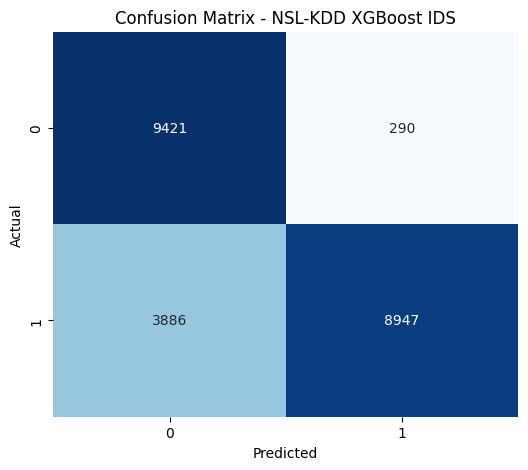

In [22]:
# =========================
# 12) Confusion Matrix
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(yb_test_full, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - NSL-KDD XGBoost IDS")
plt.show()

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Validation probabilities
probs_val = final_xgb.predict(dval)

thresholds = np.linspace(0.05, 0.6, 200)

results = []

MIN_PRECISION = 0.80  # security-friendly constraint

for t in thresholds:
    y_pred_val = (probs_val >= t).astype(int)
    prec = precision_score(y_val, y_pred_val, zero_division=0)
    rec  = recall_score(y_val, y_pred_val, zero_division=0)
    f1   = f1_score(y_val, y_pred_val, zero_division=0)

    if prec >= MIN_PRECISION:
        results.append((t, prec, rec, f1))

# Select threshold with MAX recall under precision constraint
best_t, best_p, best_r, best_f1 = max(results, key=lambda x: x[2])

print(
    f"\nChosen threshold (Recall-optimized): {best_t:.3f} | "
    f"Precision: {best_p:.4f} | Recall: {best_r:.4f} | F1: {best_f1:.4f}"
)


Chosen threshold (Recall-optimized): 0.050 | Precision: 0.9950 | Recall: 0.9998 | F1: 0.9974


In [30]:
# =========================
# 11) Evaluate on test set
# =========================
dtest = xgb.DMatrix(X_test_sel)
probs_test = final_xgb.predict(dtest)
y_test_pred = (probs_test >= best_t).astype(int)

print("\n=== FINAL EVAL (Hyper-tuned XGBoost) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(yb_test_full, y_test_pred, average="binary")
acc = (y_test_pred == yb_test_full).mean()
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


=== FINAL EVAL (Hyper-tuned XGBoost) ===
              precision    recall  f1-score   support

           0     0.7735    0.9630    0.8579      9711
           1     0.9657    0.7866    0.8670     12833

    accuracy                         0.8626     22544
   macro avg     0.8696    0.8748    0.8624     22544
weighted avg     0.8829    0.8626    0.8631     22544

Accuracy: 0.8626 | Precision: 0.9657 | Recall: 0.7866 | F1: 0.8670



Confusion Matrix (Test Set):
[[ 9352   359]
 [ 2739 10094]]

TN: 9352, FP: 359, FN: 2739, TP: 10094


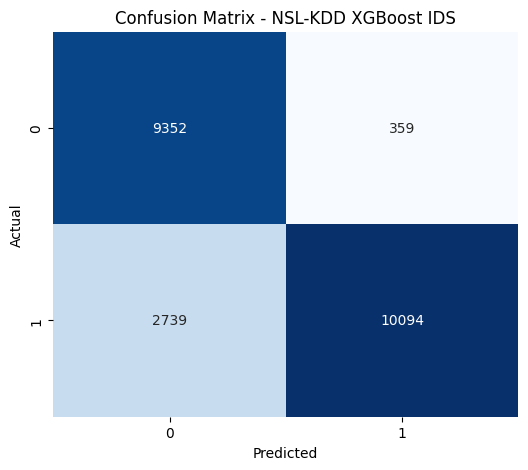

In [31]:
# =========================
# 12) Confusion Matrix
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(yb_test_full, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - NSL-KDD XGBoost IDS")
plt.show()

In [33]:
from sklearn.metrics import (
    f1_score,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
import numpy as np

# =========================
# 10) Threshold tuning (VALIDATION SET)
# =========================
dval = xgb.DMatrix(X_val_sel)
probs_val = final_xgb.predict(dval)

thresholds = np.linspace(0.10, 0.60, 101)
f1_scores = [f1_score(y_val, probs_val >= t) for t in thresholds]

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest Threshold (Val F1): {best_threshold:.3f}")
print(f"Best Validation F1: {f1_scores[best_idx]:.4f}")

# =========================
# 11) FINAL TEST EVALUATION
# =========================
dtest = xgb.DMatrix(X_test_sel)
probs_test = final_xgb.predict(dtest)
y_test_pred = (probs_test >= best_threshold).astype(int)

print("\n=== FINAL EVALUATION (RF–SMOTE + Hyper-Tuned XGBoost) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

# Core metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    yb_test_full, y_test_pred, average="binary"
)
accuracy = (y_test_pred == yb_test_full).mean()

# Ranking metrics (VERY IMPORTANT FOR IMBALANCE)
roc_auc = roc_auc_score(yb_test_full, probs_test)
pr_auc = average_precision_score(yb_test_full, probs_test)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

# =========================
# 12) Confusion Matrix
# =========================
cm = confusion_matrix(yb_test_full, y_test_pred)
print("\nConfusion Matrix:")
print(cm)


Best Threshold (Val F1): 0.495
Best Validation F1: 0.9991

=== FINAL EVALUATION (RF–SMOTE + Hyper-Tuned XGBoost) ===
              precision    recall  f1-score   support

           0     0.7076    0.9701    0.8183      9711
           1     0.9686    0.6966    0.8104     12833

    accuracy                         0.8145     22544
   macro avg     0.8381    0.8334    0.8144     22544
weighted avg     0.8562    0.8145    0.8138     22544

Accuracy : 0.8145
Precision: 0.9686
Recall   : 0.6966
F1 Score : 0.8104
ROC-AUC  : 0.9542
PR-AUC   : 0.9578

Confusion Matrix:
[[9421  290]
 [3893 8940]]


In [19]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, make_scorer

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
import xgboost as xgb
from scipy.stats import randint, uniform
import time

# =========================
# 1) Prepare data
# =========================
X_train_full = train_df.drop(columns=target_cols)
X_test_full  = test_df.drop(columns=target_cols)

yb_train_full = train_df["is_attack_binary"]
yb_test_full  = test_df["is_attack_binary"]

# =========================
# 2) Identify column types
# =========================
num_cols = X_train_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

# =========================
# 3) Preprocessing pipeline
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

# =========================
# 4) Feature selection
# =========================
K = 70  # Optimal for NSL-KDD

# =========================
# 5) Train / Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)

# =========================
# 6) Encode data
# =========================
X_tr_enc   = preprocessor.fit_transform(X_tr)
X_val_enc  = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)

# =========================
# 7) Feature selection
# =========================
selector = SelectKBest(mutual_info_classif, k=min(K, X_tr_enc.shape[1]))

X_tr_sel   = selector.fit_transform(X_tr_enc, y_tr)
X_val_sel  = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print("Encoded shape:", X_tr_enc.shape)
print("Selected shape:", X_tr_sel.shape)

# =========================
# 8) HYPERPARAMETER TUNING + SMOTE-ENN
# =========================
f1_attack = make_scorer(f1_score, pos_label=1)

pipe = ImbPipeline([
    (
        "smoteenn",
        SMOTEENN(
            sampling_strategy="auto",
            smote=None,      # default SMOTE
            enn=None,        # default 3-NN ENN
            random_state=42
        )
    ),
    (
        "clf",
        XGBClassifier(
            objective="binary:logistic",
            tree_method="hist",
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1,
            random_state=42
        )
    )
])

param_dist = {
    "clf__n_estimators": randint(300, 1200),
    "clf__max_depth": randint(3, 12),
    "clf__learning_rate": uniform(0.01, 0.25),
    "clf__min_child_weight": randint(1, 20),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__gamma": uniform(0.0, 0.5),
    "clf__reg_alpha": uniform(0.0, 1.0),
    "clf__reg_lambda": uniform(0.5, 2.0),
    "clf__scale_pos_weight": [1.0]  # IMPORTANT with SMOTE-ENN
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=f1_attack,
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

print("Starting RandomizedSearchCV with SMOTE-ENN...")
t0 = time.time()
rs.fit(X_tr_sel, y_tr)
t1 = time.time()
print(f"RandomizedSearchCV done in {(t1 - t0)/60:.2f} minutes")

print("Best CV F1 (attack):", rs.best_score_)
best_params = rs.best_params_

# =========================
# 9) Final training with xgb.train
# =========================
clf_best_params = {k.replace("clf__", ""): v for k, v in best_params.items() if k.startswith("clf__")}

smoteenn_final = SMOTEENN(random_state=42)
X_tr_bal, y_tr_bal = smoteenn_final.fit_resample(X_tr_sel, y_tr)

print("Resampled class distribution:", np.bincount(y_tr_bal))

dtrain = xgb.DMatrix(X_tr_bal, label=y_tr_bal)
dval   = xgb.DMatrix(X_val_sel, label=y_val)

params = {
    "objective": "binary:logistic",
    "tree_method": "hist",
    "learning_rate": clf_best_params["learning_rate"],
    "max_depth": int(clf_best_params["max_depth"]),
    "min_child_weight": clf_best_params["min_child_weight"],
    "subsample": clf_best_params["subsample"],
    "colsample_bytree": clf_best_params["colsample_bytree"],
    "gamma": clf_best_params["gamma"],
    "reg_alpha": clf_best_params["reg_alpha"],
    "reg_lambda": clf_best_params["reg_lambda"],
    "scale_pos_weight": 1.0,
    "eval_metric": "logloss",
    "seed": 42
}

evals = [(dtrain, "train"), (dval, "val")]

print("\nTraining final XGBoost model...")
final_xgb = xgb.train(
    params,
    dtrain,
    num_boost_round=int(clf_best_params["n_estimators"]),
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=25
)

# =========================
# 10) Threshold tuning
# =========================
probs_val = final_xgb.predict(dval)

thresholds = np.linspace(0.10, 0.60, 100)
f1s = [f1_score(y_val, probs_val >= t) for t in thresholds]

best_t = thresholds[np.argmax(f1s)]
print(f"Chosen threshold: {best_t:.3f} | Best Val F1: {max(f1s):.4f}")

# =========================
# 11) Final test evaluation
# =========================
dtest = xgb.DMatrix(X_test_sel)
probs_test = final_xgb.predict(dtest)
y_test_pred = (probs_test >= best_t).astype(int)

print("\n=== FINAL EVALUATION (SMOTE-ENN + XGBoost) ===")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(
    yb_test_full, y_test_pred, average="binary"
)

acc = (y_test_pred == yb_test_full).mean()
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")


Numeric features: 29
Categorical features: 3
Encoded shape: (107077, 112)
Selected shape: (107077, 70)
Starting RandomizedSearchCV with SMOTE-ENN...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
RandomizedSearchCV done in 28.20 minutes
Best CV F1 (attack): 0.9978199822743997
Resampled class distribution: [56869 56916]

Training final XGBoost model...
[0]	train-logloss:0.50013	val-logloss:0.50139
[25]	train-logloss:0.02363	val-logloss:0.02709
[50]	train-logloss:0.01026	val-logloss:0.01396
[75]	train-logloss:0.00563	val-logloss:0.00929
[100]	train-logloss:0.00372	val-logloss:0.00742
[125]	train-logloss:0.00268	val-logloss:0.00657
[150]	train-logloss:0.00198	val-logloss:0.00582
[175]	train-logloss:0.00157	val-logloss:0.00550
[200]	train-logloss:0.00122	val-logloss:0.00518
[225]	train-logloss:0.00102	val-logloss:0.00503
[250]	train-logloss:0.00088	val-logloss:0.00487
[275]	train-logloss:0.00075	val-logloss:0.00484
[300]	train-logloss:0.00066	val-logloss:0.00484
[325]	train-

In [ ]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, make_scorer

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from scipy.stats import randint, uniform
import time

# =========================
# 1) Prepare data
# =========================
X = train_df.drop(columns=target_cols)
y = train_df["is_attack_binary"]

X_test = test_df.drop(columns=target_cols)
y_test = test_df["is_attack_binary"]

# =========================
# 2) Identify column types
# =========================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

# =========================
# 3) Train / Validation split
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# =========================
# 4) Preprocessing
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

# =========================
# 5) Full leakage-safe pipeline
# =========================
pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("select", SelectKBest(mutual_info_classif, k=70)),
    ("smoteenn", SMOTEENN(random_state=42)),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    ))
])

# =========================
# 6) Hyperparameter space
# =========================
param_dist = {
    "select__k": [40,50, 60, 70, 80],
    "clf__n_estimators": randint(300, 1000),
    "clf__max_depth": randint(3, 10),
    "clf__learning_rate": uniform(0.02, 0.2),
    "clf__min_child_weight": randint(1, 15),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__gamma": uniform(0.0, 0.5),
    "clf__reg_alpha": uniform(0.0, 1.0),
    "clf__reg_lambda": uniform(0.5, 2.0),
    "clf__scale_pos_weight": [1.0]  # REQUIRED with SMOTE-ENN
}

# =========================
# 7) CV setup
# =========================
f1_attack = make_scorer(f1_score, pos_label=1)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring=f1_attack,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

# =========================
# 8) Hyperparameter tuning
# =========================
print("\nStarting RandomizedSearchCV (Leakage-Safe)...")
start = time.time()
rs.fit(X_tr, y_tr)
end = time.time()

print(f"\nSearch completed in {(end - start)/60:.2f} minutes")
print("Best CV F1 (attack):", rs.best_score_)
print("Best parameters:", rs.best_params_)

best_model = rs.best_estimator_

# =========================
# 9) Threshold tuning (VALIDATION SET)
# =========================
probs_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.10, 0.60, 100)
f1_scores = [f1_score(y_val, probs_val >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\nBest threshold: {best_threshold:.3f}")
print(f"Validation F1: {max(f1_scores):.4f}")

# =========================
# 10) Final test evaluation
# =========================
probs_test = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (probs_test >= best_threshold).astype(int)

print("\n=== FINAL TEST RESULTS (SMOTE-ENN + XGBoost) ===")
print(classification_report(y_test, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="binary"
)

accuracy = (y_test_pred == y_test).mean()

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")  
print(f"F1-score : {f1:.4f}")


Numeric features: 29
Categorical features: 3

Starting RandomizedSearchCV (Leakage-Safe)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Search completed in 156.99 minutes
Best CV F1 (attack): 0.9979809329559927
Best parameters: {'clf__colsample_bytree': np.float64(0.7644148053272926), 'clf__gamma': np.float64(0.016525366450274193), 'clf__learning_rate': np.float64(0.0890142496053366), 'clf__max_depth': 3, 'clf__min_child_weight': 3, 'clf__n_estimators': 937, 'clf__reg_alpha': np.float64(0.1448948720912231), 'clf__reg_lambda': np.float64(1.478905520555126), 'clf__scale_pos_weight': 1.0, 'clf__subsample': np.float64(0.9942601816442402), 'select__k': 70}

Best threshold: 0.201
Validation F1: 0.9987

=== FINAL TEST RESULTS (SMOTE-ENN + XGBoost) ===
              precision    recall  f1-score   support

           0     0.6933    0.9723    0.8094      9711
           1     0.9699    0.6745    0.7957     12833

    accuracy                         0.8028     22544
   macro

In [74]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


train_normal = train_df[train_df['is_attack_binary'] == 0]

X_train_normal = train_normal.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

X_test = test_df.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

y_test = test_df['is_attack_binary']

In [75]:
num_features = X_train_normal.select_dtypes(include=['int64','float64']).columns
cat_features = X_train_normal.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train_normal)
X_test_proc = preprocessor.transform(X_test)

input_dim = X_train_proc.shape[1]


In [76]:
def build_autoencoder(input_dim,
                      hidden_1=128,
                      hidden_2=64,
                      bottleneck=16,
                      lr=0.001):

    input_layer = Input(shape=(input_dim,))

    # Encoder
    x = Dense(hidden_1, activation='relu')(input_layer)
    x = Dense(hidden_2, activation='relu')(x)
    bottleneck_layer = Dense(bottleneck, activation='relu')(x)

    # Decoder
    x = Dense(hidden_2, activation='relu')(bottleneck_layer)
    x = Dense(hidden_1, activation='relu')(x)

    output_layer = Dense(input_dim, activation='linear')(x)

    model = Model(input_layer, output_layer)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse'
    )

    return model


In [77]:
# param_grid = [
#     {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 16, 'lr': 1e-3},
#     {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 32, 'lr': 1e-3},
#     {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 16, 'lr': 1e-3},
#     {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 32, 'lr': 1e-4},
# ]

In [78]:
param_grid = [
    # Shallow compression
    {'hidden_1': 128, 'hidden_2': 64,  'bottleneck': 8,  'lr': 1e-3},
    {'hidden_1': 128, 'hidden_2': 64,  'bottleneck': 16, 'lr': 1e-3},
    {'hidden_1': 128, 'hidden_2': 64,  'bottleneck': 32, 'lr': 1e-3},

    # Medium depth
    {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 8,  'lr': 1e-3},
    {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 16, 'lr': 1e-3},
    {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 32, 'lr': 1e-3},

    # Lower learning rate (stability)
    {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 8,  'lr': 5e-4},
    {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 16, 'lr': 5e-4},

    # Higher capacity (careful)
    {'hidden_1': 512, 'hidden_2': 256, 'bottleneck': 16, 'lr': 1e-4},
    {'hidden_1': 512, 'hidden_2': 256, 'bottleneck': 32, 'lr': 1e-4},
]


In [79]:
best_model = None
best_val_loss = np.inf
best_params = None

for params in param_grid:
    print("\nTraining with params:", params)

    model = build_autoencoder(
        input_dim=input_dim,
        hidden_1=params['hidden_1'],
        hidden_2=params['hidden_2'],
        bottleneck=params['bottleneck'],
        lr=params['lr']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_proc,
        X_train_proc,
        epochs=50,
        batch_size=256,
        validation_split=0.15,
        shuffle=True,
        callbacks=[early_stop],
        verbose=0
    )

    val_loss = min(history.history['val_loss'])
    print("Validation Loss:", val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params



Training with params: {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 8, 'lr': 0.001}
Validation Loss: 0.011470084078609943

Training with params: {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 16, 'lr': 0.001}
Validation Loss: 0.011828179471194744

Training with params: {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 32, 'lr': 0.001}
Validation Loss: 0.006789591629058123

Training with params: {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 8, 'lr': 0.001}
Validation Loss: 0.009802169166505337

Training with params: {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 16, 'lr': 0.001}
Validation Loss: 0.005532755516469479

Training with params: {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 32, 'lr': 0.001}
Validation Loss: 0.007552456576377153

Training with params: {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 8, 'lr': 0.0005}
Validation Loss: 0.009067107923328876

Training with params: {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 16, 'lr': 0.0005}
Validation Loss: 0.0065968

In [80]:
print("\nBEST PARAMETERS FOUND:")
print(best_params)


BEST PARAMETERS FOUND:
{'hidden_1': 512, 'hidden_2': 256, 'bottleneck': 32, 'lr': 0.0001}


In [81]:
# Reconstruction error on normal data
train_pred = best_model.predict(X_train_proc)
train_error = np.mean(
    np.square(X_train_proc - train_pred),
    axis=1
)

# Try multiple percentiles
percentiles = [95, 97, 99]

for p in percentiles:
    threshold = np.percentile(train_error, p)

    test_pred = best_model.predict(X_test_proc)
    test_error = np.mean(
        np.square(X_test_proc - test_pred),
        axis=1
    )

    y_pred = (test_error > threshold).astype(int)

    print(f"\nThreshold = {p}th percentile")
    print(classification_report(y_test, y_pred))


2105/2105 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Threshold = 95th percentile
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      9711
           1       0.92      0.92      0.92     12833

    accuracy                           0.91     22544
   macro avg       0.90      0.90      0.90     22544
weighted avg       0.91      0.91      0.91     22544

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Threshold = 97th percentile
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      9711
           1       0.92      0.89      0.90     12833

    accuracy                           0.89     22544
   macro avg       0.89      0.89      0.89     22544
weighted avg       0.89      0.89      0.89     22544

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Threshold = 99th percentile
              precision    recall  f1-score   support

           0       0.79      0.92     

In [82]:
# -------------------------------
# Final threshold (example: 97%)
# -------------------------------
threshold = np.percentile(train_error, 95)

# Reconstruction error on test data
test_pred = best_model.predict(X_test_proc)
test_error = np.mean(
    np.square(X_test_proc - test_pred),
    axis=1
)

# Binary predictions
# 1 = attack (anomaly), 0 = normal
y_pred_ae = (test_error > threshold).astype(int)


705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_ae)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 8659  1052]
 [ 1052 11781]]


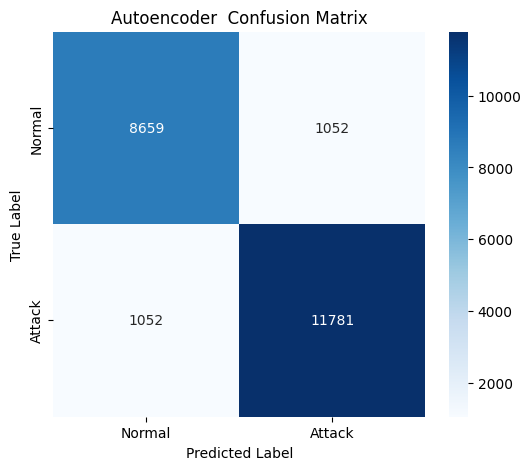

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Autoencoder  Confusion Matrix")
plt.show()


In [49]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
train_normal = train_df[train_df['is_attack_binary'] == 0]

X_train_normal = train_normal.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

X_test = test_df.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

y_test = test_df['is_attack_binary']


In [52]:
num_features = X_train_normal.select_dtypes(include=['int64','float64']).columns
cat_features = X_train_normal.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train_normal)
X_test_proc = preprocessor.transform(X_test)

input_dim = X_train_proc.shape[1]

print("Train shape:", X_train_proc.shape)
print("Test shape:", X_test_proc.shape)

Train shape: (67343, 68)
Test shape: (22544, 68)


In [53]:
def build_denoising_autoencoder(
    input_dim,
    hidden_1=128,
    hidden_2=64,
    bottleneck=16,
    lr=0.001,
    noise_std=0.05
):

    inputs = Input(shape=(input_dim,))
    noisy = GaussianNoise(noise_std)(inputs)

    # Encoder
    x = Dense(hidden_1, activation='relu')(noisy)
    x = Dense(hidden_2, activation='relu')(x)
    bottleneck_layer = Dense(bottleneck, activation='relu')(x)

    # Decoder
    x = Dense(hidden_2, activation='relu')(bottleneck_layer)
    x = Dense(hidden_1, activation='relu')(x)
    outputs = Dense(input_dim, activation='linear')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=tf.keras.losses.Huber(delta=1.0)  # robust loss
    )

    return model

In [54]:
tf.random.set_seed(42)
np.random.seed(42)

autoencoder = build_denoising_autoencoder(
    input_dim=input_dim,
    hidden_1=128,
    hidden_2=64,
    bottleneck=16,
    lr=0.001,
    noise_std=0.05
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_proc,
    X_train_proc,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0386 - val_loss: 0.0169
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0141 - val_loss: 0.0131
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0100 - val_loss: 0.0092
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0078 - val_loss: 0.0079
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0068 - val_loss: 0.0071
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0061 - val_loss: 0.0065
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0057 - val_loss: 0.0062
Epoch 8/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0054 - val_loss: 0.0059
Epoch 9/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0050 - val_loss: 0.0052
Epoch 10/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0045 - val_loss: 0.0048
Epoch 11/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0041 - val_loss: 0.0046
Epoch 12/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10

In [55]:
# Train reconstruction error (NORMAL)
train_pred = autoencoder.predict(X_train_proc)
train_error = np.mean(
    np.square(X_train_proc - train_pred),
    axis=1
)

# Test reconstruction error
test_pred = autoencoder.predict(X_test_proc)
test_error = np.mean(
    np.square(X_test_proc - test_pred),
    axis=1
)


2105/2105 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [56]:
threshold = np.percentile(train_error, 95)
print("Anomaly Threshold:", threshold)

# Final predictions
y_pred_ae = (test_error > threshold).astype(int)


Anomaly Threshold: 0.007815066934324398


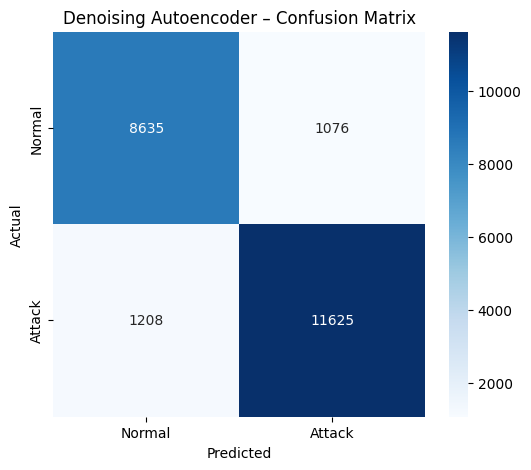

In [57]:
cm = confusion_matrix(y_test, y_pred_ae)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Denoising Autoencoder – Confusion Matrix")
plt.show()


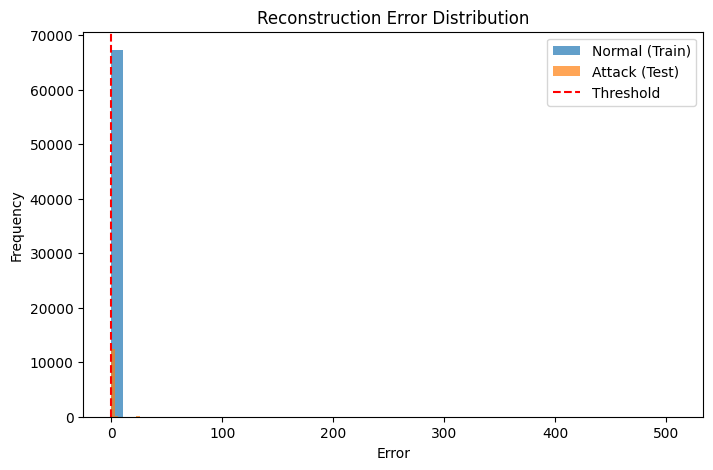

In [58]:
plt.figure(figsize=(8,5))
plt.hist(train_error, bins=50, alpha=0.7, label="Normal (Train)")
plt.hist(test_error[y_test == 1], bins=50, alpha=0.7, label="Attack (Test)")
plt.axvline(threshold, color='red', linestyle='--', label="Threshold")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


In [59]:
# Reconstruction error on normal data
train_pred = best_model.predict(X_train_proc)
train_error = np.mean(
    np.square(X_train_proc - train_pred),
    axis=1
)

# Try multiple percentiles
percentiles = [95, 97, 99]

for p in percentiles:
    threshold = np.percentile(train_error, p)

    test_pred = best_model.predict(X_test_proc)
    test_error = np.mean(
        np.square(X_test_proc - test_pred),
        axis=1
    )

    y_pred = (test_error > threshold).astype(int)

    print(f"\nThreshold = {p}th percentile")
    print(classification_report(y_test, y_pred))


2105/2105 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Threshold = 95th percentile
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      9711
           1       0.92      0.91      0.92     12833

    accuracy                           0.91     22544
   macro avg       0.90      0.90      0.90     22544
weighted avg       0.91      0.91      0.91     22544

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Threshold = 97th percentile
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      9711
           1       0.92      0.88      0.90     12833

    accuracy                           0.89     22544
   macro avg       0.89      0.89      0.89     22544
weighted avg       0.89      0.89      0.89     22544

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Threshold = 99th percentile
              precision    recall  f1-score   support

           0       0.78      0.92     

In [60]:
import numpy as np
import pandas as pd

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# XGBoost
from xgboost import XGBClassifier


In [61]:
X_train = train_df.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

y_train_bin = train_df['is_attack_binary']
y_train_multi = train_df['is_attack_multiclass']

X_test = test_df.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

y_test_bin = test_df['is_attack_binary']
y_test_multi = test_df['is_attack_multiclass']

In [63]:
num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat',OneHotEncoder(handle_unknown="ignore", sparse_output=False) , cat_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)


In [64]:
def build_autoencoder(input_dim, bottleneck=16, lr=1e-3):
    inp = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inp)
    x = Dense(64, activation='relu')(x)
    bottleneck_layer = Dense(bottleneck, activation='relu')(x)
    x = Dense(64, activation='relu')(bottleneck_layer)
    x = Dense(128, activation='relu')(x)
    out = Dense(input_dim, activation='linear')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(lr), loss='mse')
    return model


In [65]:
# NORMAL traffic only
X_train_normal = X_train_proc[y_train_bin == 0]

autoencoder = build_autoencoder(
    input_dim=X_train_proc.shape[1],
    bottleneck=16,
    lr=1e-3
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0624 - val_loss: 0.0623
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0158 - val_loss: 0.0435
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0096 - val_loss: 0.0114
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0064 - val_loss: 0.0066
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0058 - val_loss: 0.0074
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0053 - val_loss: 0.0068
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0046 - val_loss: 0.0077
Epoch 8/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0044 - val_loss: 0.0084
Epoch 9/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0040 - val_loss: 0.0080


In [66]:
train_recon = autoencoder.predict(X_train_normal)
train_error = np.mean(
    np.square(X_train_normal - train_recon),
    axis=1
)

threshold = np.percentile(train_error, 95)
print("Anomaly Threshold:", threshold)


2105/2105 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Anomaly Threshold: 0.022323693549616518


In [68]:
from sklearn.preprocessing import LabelEncoder

# Encode attack categories
attack_encoder = LabelEncoder()

y_attack_encoded = attack_encoder.fit_transform(
    y_train_multi[y_train_bin == 1]
)

X_attack = X_train_proc[y_train_bin == 1]

print("Attack class mapping:")
for i, cls in enumerate(attack_encoder.classes_):
    print(i, "->", cls)

Attack class mapping:
0 -> dos
1 -> probe
2 -> r2l
3 -> u2r


In [69]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_attack, y_attack_encoded)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [70]:
# Autoencoder anomaly detection
test_recon = autoencoder.predict(X_test_proc)
test_error = np.mean(
    np.square(X_test_proc - test_recon),
    axis=1
)

is_anomaly = (test_error > threshold)

hybrid_pred = np.zeros(len(X_test_proc), dtype=object)
hybrid_pred[~is_anomaly] = "normal"

# Predict encoded labels
encoded_preds = xgb.predict(X_test_proc[is_anomaly])

# Decode back to attack names
hybrid_pred[is_anomaly] = attack_encoder.inverse_transform(encoded_preds)


705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [71]:
hybrid_bin_pred = np.where(hybrid_pred == "normal", 0, 1)

print("HYBRID IDS – BINARY REPORT")
print(classification_report(y_test_bin, hybrid_bin_pred))


HYBRID IDS – BINARY REPORT
              precision    recall  f1-score   support

           0       0.77      0.92      0.84      9711
           1       0.93      0.80      0.86     12833

    accuracy                           0.85     22544
   macro avg       0.85      0.86      0.85     22544
weighted avg       0.86      0.85      0.85     22544



In [72]:
known_attack_mask = (y_test_bin == 1) & is_anomaly

print("HYBRID IDS – MULTICLASS REPORT")
print(
    classification_report(
        y_test_multi[known_attack_mask],
        hybrid_pred[known_attack_mask]
    )
)

HYBRID IDS – MULTICLASS REPORT
              precision    recall  f1-score   support

         dos       0.97      0.90      0.93      6967
       probe       0.69      0.93      0.79      2294
         r2l       0.96      0.81      0.88       791
         u2r       0.89      0.16      0.27       157

    accuracy                           0.88     10209
   macro avg       0.88      0.70      0.72     10209
weighted avg       0.91      0.88      0.89     10209



In [73]:
cm = confusion_matrix(y_test_bin, hybrid_bin_pred)

print("HYBRID CONFUSION MATRIX")
print(cm)


HYBRID CONFUSION MATRIX
[[ 8893   818]
 [ 2624 10209]]
